# Import 

In [152]:
import h5py
from seisbench.models import CRED,EQTransformer,PhaseNet,GPD,OBSTransformer
import numpy as np
from seisbench.data import WaveformDataset
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
from obspy import Stream, Trace
from tqdm import  tqdm 
import matplotlib.transforms as mtransforms
import nest_asyncio
nest_asyncio.apply()
import datetime

from sklearn.metrics import recall_score, balanced_accuracy_score

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn


global clockt1

def tic():
    global clockt0
    clockt0 = datetime.datetime.now()

def toc():
    global clockt1
    clockt1 = datetime.datetime.now()

def tac():
    global clockt1
    global clockt0
    d = clockt1 - clockt0
    return d.total_seconds()
    
def try_treshold(prob,labels):
    VecR = []
    VecA = []
    px= np.arange(0,1,0.01)
    for p in  px : 
        #Score = np.sum([ip>p for ip in prob])/len(prob)*100
        VecR.append(recall_score(labels,[ip>p for ip in prob]))
        VecA.append(balanced_accuracy_score(labels,[ip>p for ip in prob]))
    return np.array(VecR),px,np.array(VecA)

def try_SNR(prob,SNR,labels):
    VecR = []
    VecA = []
    Nv= []
    px= list(np.arange(0,8,1))
    SNR = np.array(SNR)
    SNR[SNR>px[-1]] = px[-2]
    classe = np.array([ip>0.50 for ip in prob])
    for k in range(len(px)-1) : 
        iisnr=np.where( (SNR>=px[k]) & (SNR<px[k+1]))
        #Score = np.sum( [ip>0.50 for ip in prob[iisnr]] )/(len(prob[iisnr]) + 1e-11)*100 *(np.nan,1)[len(prob[ii])>0]
        Nv  = Nv+[len(iisnr[0])]
        if Nv[-1]>0:
            VecR.append(recall_score(labels[iisnr],classe[iisnr]))
            VecA.append(balanced_accuracy_score(labels[iisnr],classe[iisnr]))
        else:
            VecR.append(0)
            VecA.append(0)
    return np.array(VecR),np.array(px), Nv,np.array(VecA)


plt.rcParams.update({
    'font.size': 22,
    'axes.titlesize': 24,
    'figure.titlesize': 26  # Taille du titre de la figure
})

"""
axes.titlesize : 24
axes.labelsize : 20
lines.linewidth : 3
lines.markersize : 10
xtick.labelsize : 16
ytick.labelsize : 16
"""
def plotprobs(prob,labels):
    bins=np.arange(0,1.1,0.1)
    selection = np.where(labels==0)
    recp , px , accp = try_treshold(1-prob[selection],[1]*len(selection[0]))
    figdist = plt.figure(figsize=(25,6))
    plt.subplot(1,3,1)
    plt.hist(1-prob[selection],bins=bins,cumulative=False,density=False,color='k')
    plt.ylabel('Number')
    plt.xlabel('Noise Probability')
    plt.twinx()
    plt.plot(px,accp,color='r',ls='-',lw=4)
    plt.ylabel('Recall/Accuracy')
    plt.title('Noise class Probablity')
    plt.subplot(1,3,2)
    selection = np.where(labels==1)
    recp , px , accp = try_treshold(prob[selection],[1]*len(selection[0]))
    plt.hist(prob[selection],bins=bins,cumulative=False,density=False,color='k')
    plt.ylabel('Number')
    plt.xlabel('Signal Probability')
    plt.twinx()
    plt.plot(px,accp,color='r',ls='-',lw=4)
    plt.ylabel('Recall/Accuracy')
    plt.title('Signal class Probablity')

    plt.subplot(1,3,3)
    recp , px , accp = try_treshold(prob,labels)
    plt.hist([prob[i] if labels[i]==1 else 1-prob[i] for i in range(len(prob))],bins=bins,cumulative=False,density=False,color='k')
    plt.ylabel('Number')
    plt.xlabel('Class Probability')
    ax =plt.twinx()
    plt.plot(px,accp,color='#712F79',ls='-',label='Accuracy',lw=4)
    plt.plot(px,recp,color='#48639C',ls='-',label='Recall',lw=4)
    f1sc=2*accp*recp/(recp+accp+1e-11)
    plt.plot(px, f1sc, color='#F7999E',ls='-',label='F1-scor',lw=4)
    plt.ylabel('Recall/Accuracy')
    plt.legend(loc='lower right')
    plt.title('Combined class Probablity')
    ima = np.argmax(f1sc)
    plt.axvline(x=px[ima],ls=':',color='red')
    trans_offset = mtransforms.offset_copy(ax.transData, fig=figdist,
                                       x=0.05, y=0.10, units='inches')
    plt.text(px[ima], (np.nanmax(f1sc)+np.nanmin(f1sc))/2, f' {f1sc[ima]:.2f} at {px[ima]:.2f} ', dict(size=18),
             transform=trans_offset,
             horizontalalignment='center',
             verticalalignment='bottom',
             color ='red')
    plt.tight_layout()
    plt.show()

    snrrec, snrx , Nv,snracc = try_SNR(prob,np.array(SNR),labels)
    figsnr=plt.figure(figsize=(9,5))
    n=1*3
    offset=(1/n)
    plt.bar(snrx[:-1]/2+snrx[1:]/2 - 2/3 * offset,snrrec,width=1/(2*n),label='Recall',color='#48639C')
    plt.bar(snrx[:-1]/2+snrx[1:]/2 ,snracc,width=1/(2*n),label='Accuracy',color='#712F79')
    plt.bar(snrx[:-1]/2+snrx[1:]/2 + 2/3* offset,2*snracc*snrrec/(snrrec+snracc+1e-11),width=1/(2*n),label='F1-score',color='#F7999E')
    plt.xlabel('SNR')
    plt.ylabel('Score')
    plt.legend(loc='lower right')
    plt.twinx()
    plt.plot(snrx[:-1]/2+snrx[1:]/2,Nv,color='k',ls = ':',lw=4)
    plt.ylabel('Number')
    plt.title('Score at 50% treshold against SNR ')
    plt.show()

    return figdist,figsnr, [f1sc[ima],px[ima]]
    
def convert_1d_to_3d(waveform_1d):
    # Repeat the 1D waveform for all 3 components
    return torch.stack([waveform_1d, waveform_1d, waveform_1d], dim=0)

def pad_to_multiple(x, multiple=256):
    length = x.shape[-1]
    pad_len = (multiple - length % multiple) % multiple
    if pad_len > 0:
        x = F.pad(x, (0, pad_len))
    return x
    
sampling_rate = 100#10e6
class CustomWaveformDataset_Seisbench(torch.utils.data.Dataset):
    def __init__(self, paths, labeldatas, times,waveforms):
        self.paths = paths
        self.labels = labels
        self.times = times
        self.waveforms = waveforms
        
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        waveform_stacked = self.waveforms[idx]
        waveforms_np = pad_to_multiple(torch.tensor(waveform_stacked), multiple=256).numpy()
        st = Stream()

        # Create a Trace for each component
        for i, component in enumerate(waveforms_np):
            trace = Trace(data=component)
            trace.stats.channel = f"Component_{i+1}"  # Name the channels
            trace.stats.sampling_rate = sampling_rate
    
            st.append(trace)
        
        waveform_3d = st
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return waveform_3d, label

class CustomWaveformDataset_IsAE(torch.utils.data.Dataset):
    def __init__(self, paths, labeldatas, times,waveform,Spectrograms):
        self.paths = paths
        self.labels = labels
        self.times = times
        self.waveforms = waveforms
        self.Spectrograms =  Spectrograms
        
    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        
        return  torch.tensor(self.Spectrograms[idx]), _

def  MakeSNR(waveforms):
    #SNR = [np.nanmax(np.abs(waveform[1]))/(np.max(np.abs(waveform[1][:len(waveform[1])//6]))+1e-11) for waveform in waveforms ]
    rms = lambda y : np.sqrt(np.mean(y**2))
    SNR = [rms(waveform[0])/(rms(waveform[1][:len(waveform[0])//6])+1e-11) for waveform in waveforms ]
   
    #SNR = [ signaltonoise(waveform[0]) for waveform in waveforms ]
    return SNR


# Testing on SeisBench Available Models and IsAE on Our Dataset

## load data

In [133]:
file = 'dataset_all'
with h5py.File(f'{file}.h5', 'r') as f:
    # Load waveforms and labels

    labels = f['labels'][:]
    waveforms = f['waveforms'][:]
    # Load metadata
    paths = f.attrs['paths']
    times = f.attrs['times']
    Spectrogram  = f['spectrograms'][:]
    
    SNR = MakeSNR(waveforms)

print(f"Dataset loaded from '{file}.h5'.")
print('Number of elements : ',len(paths))

# Initialize the dataset For Natural Trained Earthquakes
dataset = CustomWaveformDataset_Seisbench(paths, labels, times, waveforms)

Dataset loaded from 'dataset_all.h5'.
Number of elements :  2193


In [146]:
## Iniatialize Best rate dic
BestP1 = {}
BestT1 = {}

In [3]:
print(dataset[0][0])  # Should be (3, num_samples) for 3-component data
print(dataset[0])

3 Trace(s) in Stream:
...Component_1 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_2 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_3 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
(<obspy.core.stream.Stream object at 0x7fbc094a0380>, tensor(1))


## Cred

In [134]:
# Load the pre-trained model
print(CRED.list_pretrained())
model = CRED.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'lendb', 'original', 'scedc', 'stead']


CRED(
  (conv1): Conv2d(3, 8, kernel_size=(9, 9), stride=(2, 2), padding=(4, 4))
  (cnn_block1): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(8, 8, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (cnn_block2): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (lstm_block): BlockBiLSTM(
    (dropout): Dropout(p=0.3, inplace=False)
    (lstms): ModuleList(
      (0): LSTM(176, 64, batch_first=True, bidirectional=True)
      (1): LSTM(128, 64, batch_first=True, bidirectional=True)
    )
  )
  (lstm): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.

In [135]:

pred_list = []
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )
    
pred_list_Cred1 = np.array(pred_list)

  6%|▋         | 141/2193 [00:01<00:20, 98.49it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7fbc09494dc0> is already entered
 30%|███       | 660/2193 [00:06<00:15, 101.72it/s]Task was destroyed but it is pending!
task: <Task pending name='Task-146008' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-146009' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark

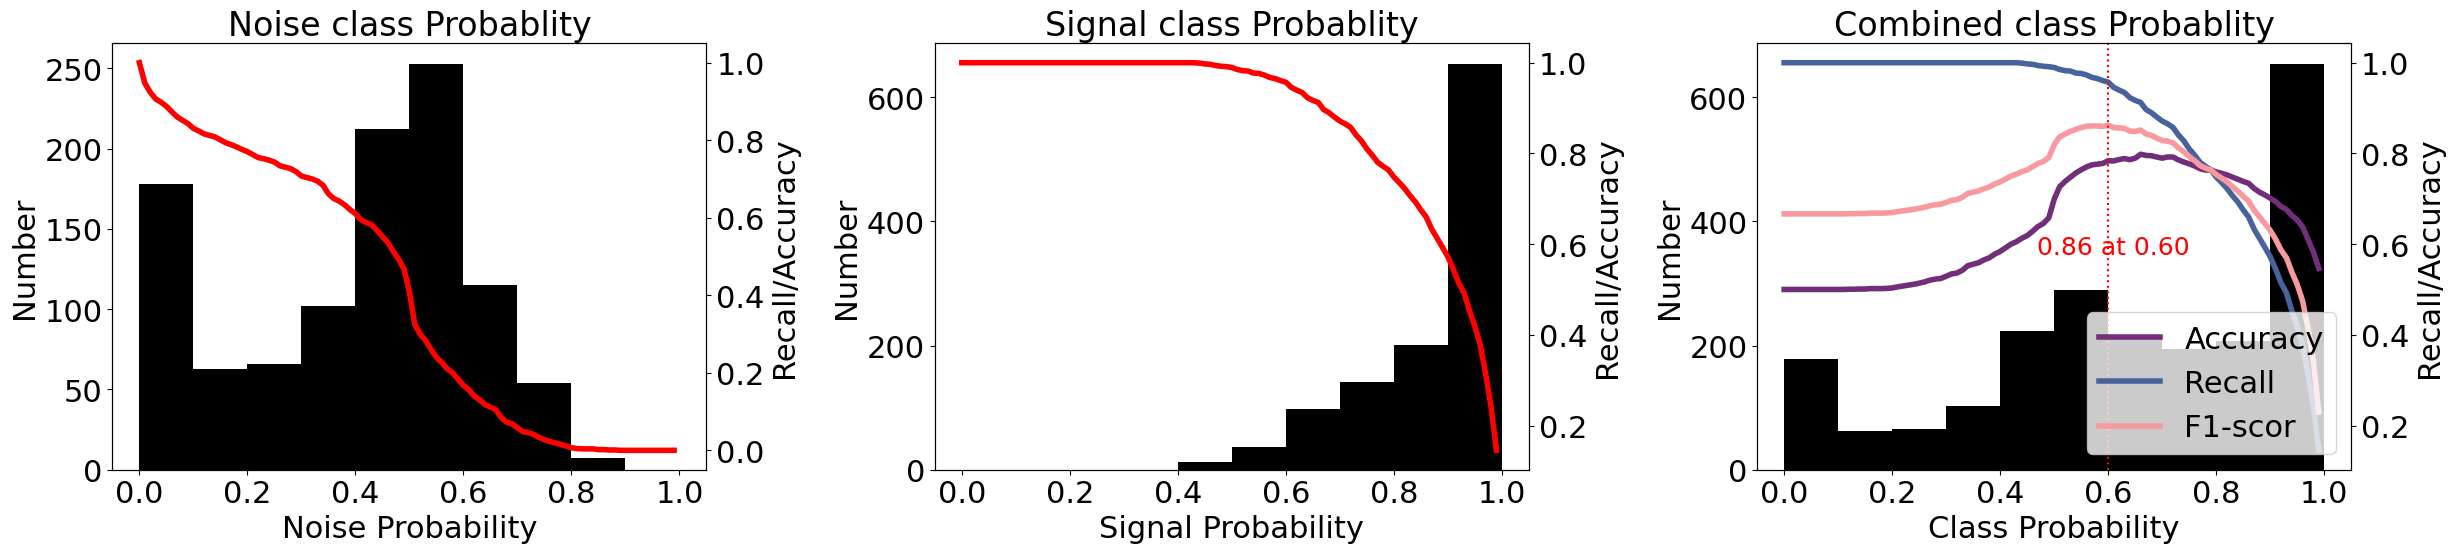

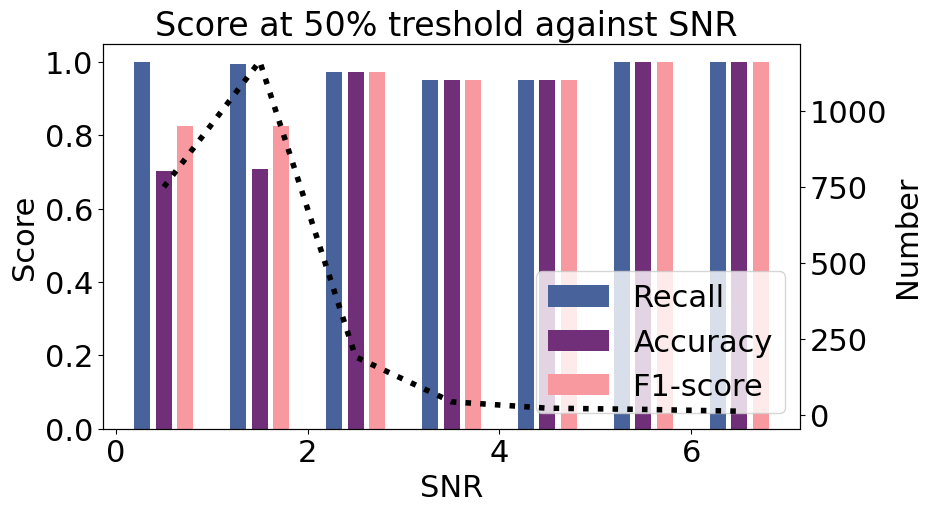

In [163]:
f1,f2, L = plotprobs(pred_list_Cred1,labels)
BestRuntimeError: Tried to serialize object __torch__.___torch_mangle_15.Classifier which does not have a __getstate__ method defined!RuntimeError: Tried to serialize object __torch__.___torch_mangle_15.Classifier which does not have a __getstate__ method defined!1['Cred'] = L[0]
BestT1['Cred'] = L[1]
f1.savefig("Figure/CRED_Prob_OD.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/CRED_Snr_OD.png", dpi=100, bbox_inches='tight')

## EQTransformer

In [137]:
# Load the pre-trained model
print(EQTransformer.list_pretrained())
model = EQTransformer.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'obs', 'original', 'original_nonconservative', 'scedc', 'stead', 'volpick']


EQTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.1, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(

In [138]:
%autoawait off
pred_list = []
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )

pred_list_EQT1 = np.array(pred_list)

100%|██████████| 2193/2193 [01:59<00:00, 18.33it/s]


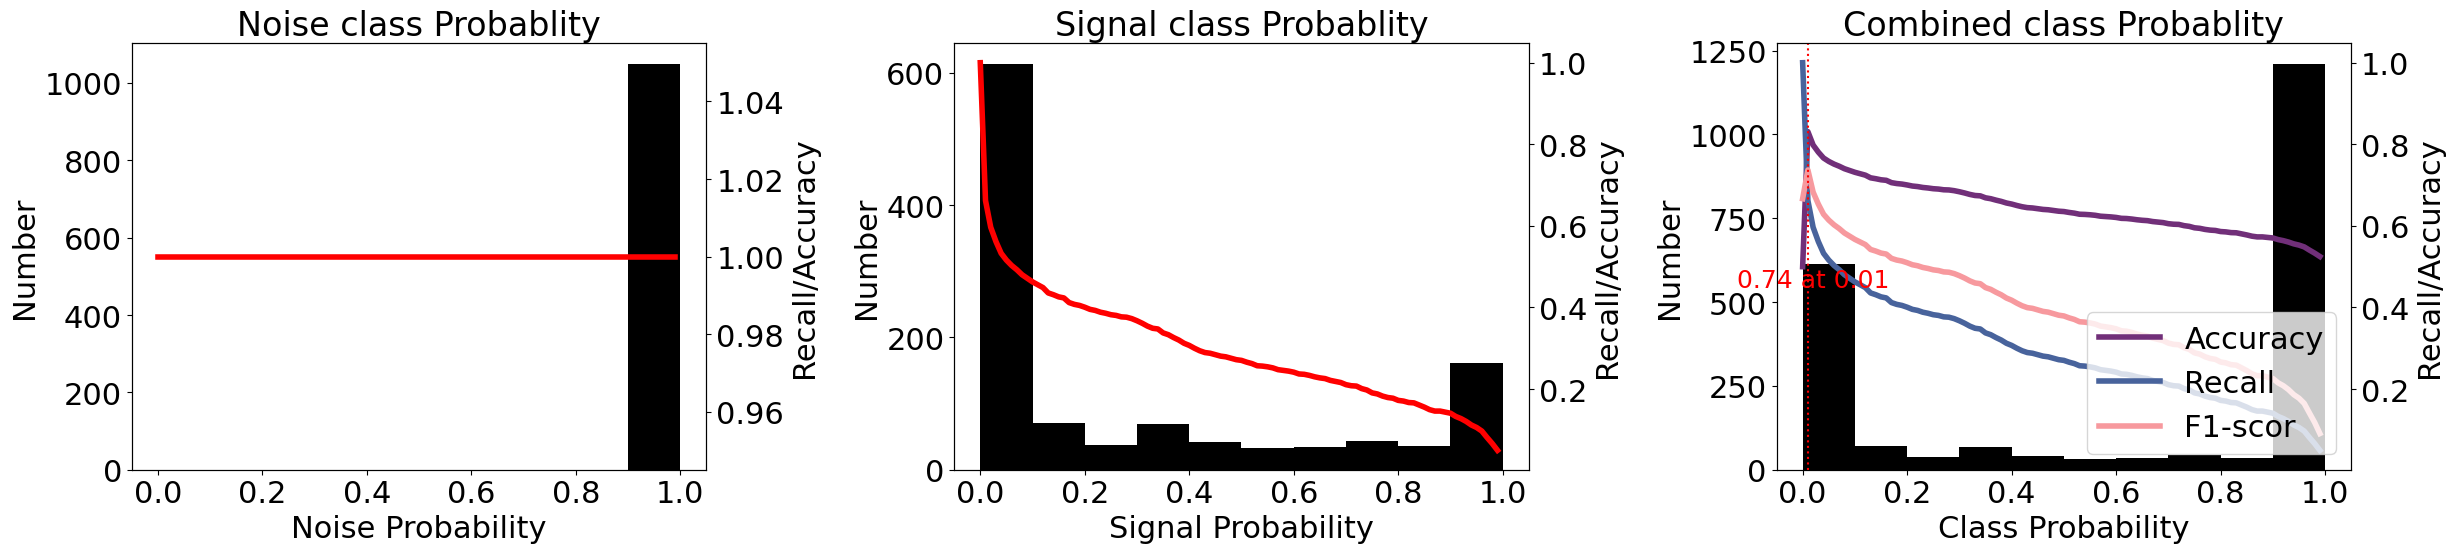

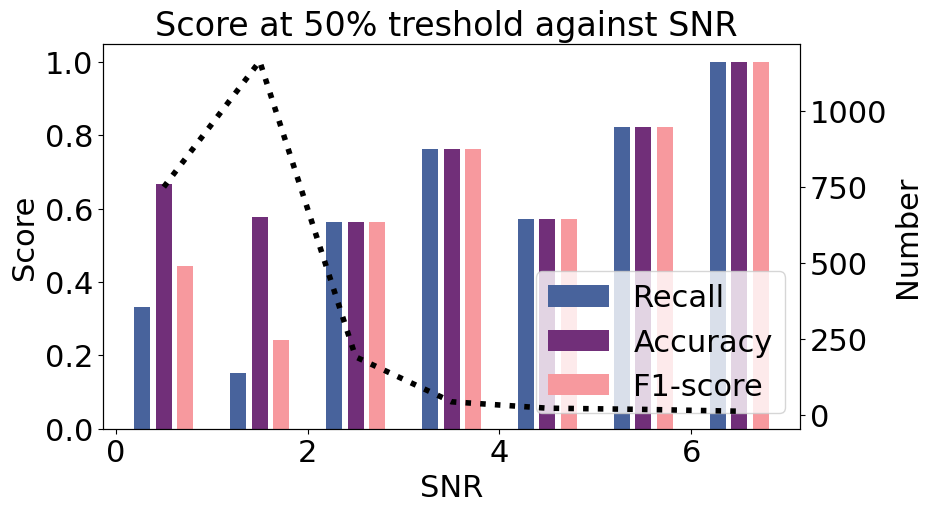

In [164]:
f1,f2, L = plotprobs(pred_list_EQT1,labels)
BestP1['EQT'] = L[0]
BestT1['EQT'] = L[1]
f1.savefig("Figure/EQT_Prob_OD.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/EQT_Snr_OD.png", dpi=100, bbox_inches='tight')

## GPD

In [140]:
## # Load the pre-trained PhaseNet model
print(GPD.list_pretrained())
model = GPD.from_pretrained("original")
model.to('cpu:0')

['dummy', 'ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'original', 'scedc', 'stead']


GPD(
  (conv1): Conv1d(3, 32, kernel_size=(21,), stride=(1,), padding=(10,))
  (bn1): BatchNorm1d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(15,), stride=(1,), padding=(7,))
  (bn2): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn3): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv1d(128, 256, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn4): BatchNorm1d(256, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=6400, out_features=200, bias=True)
  (bn5): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (bn6): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=200, out_featu

In [ ]:
%autoawait on

pred_list = []
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )

pred_list_GPD1 = np.array(pred_list)

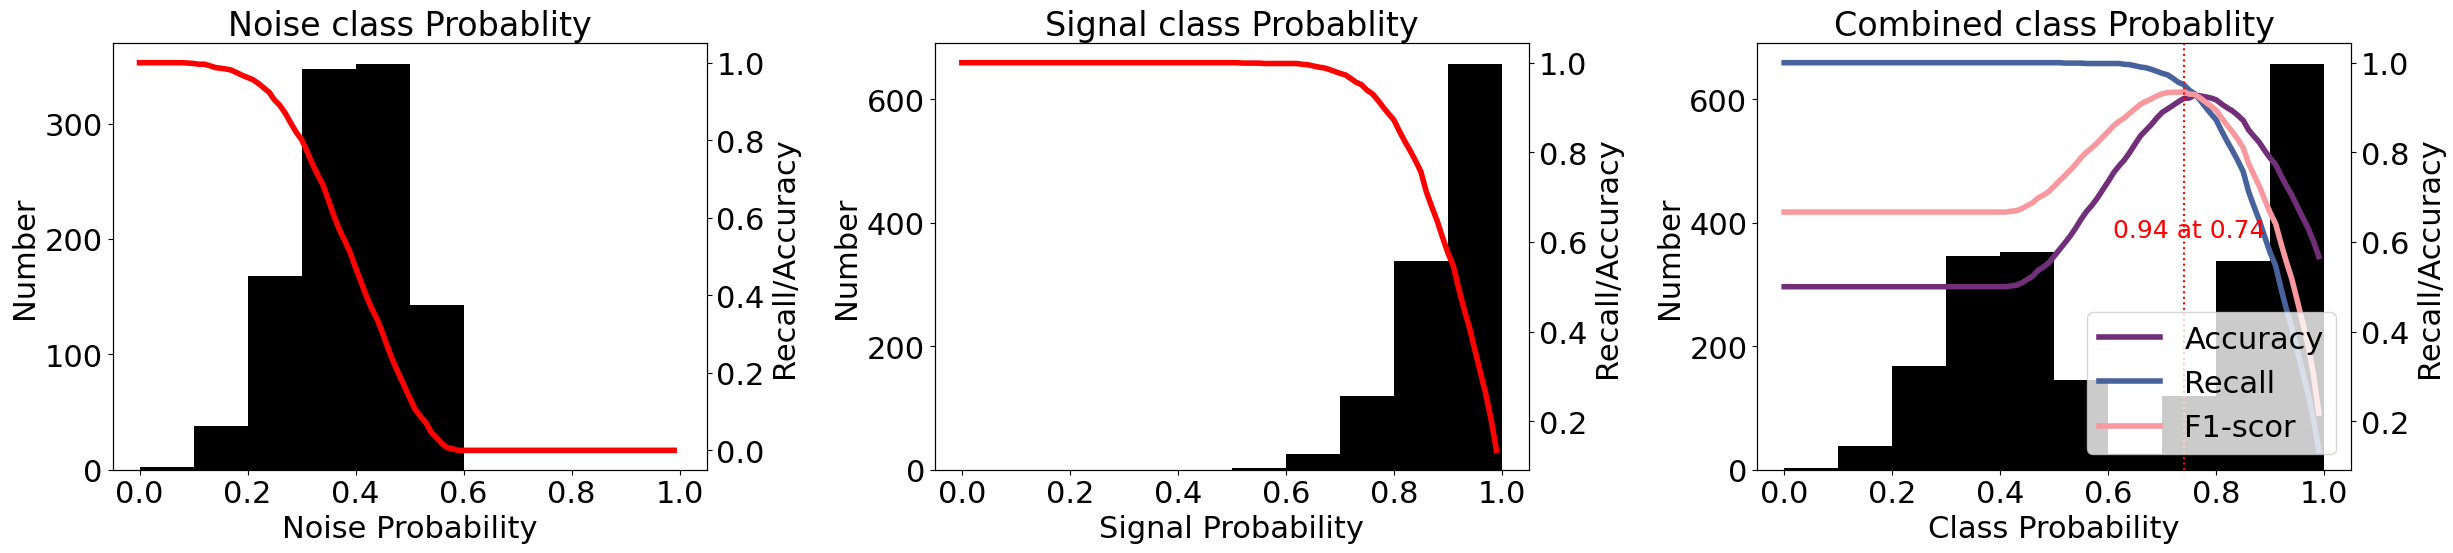

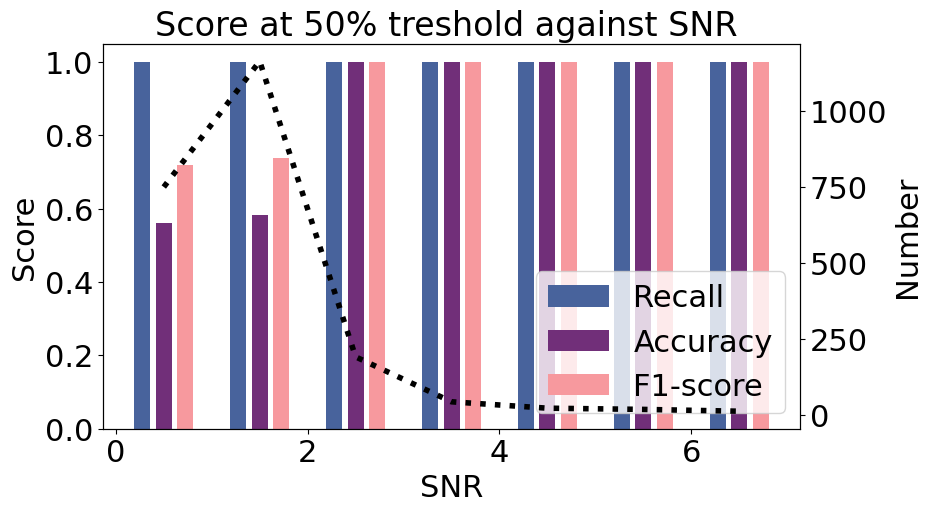

In [165]:
f1,f2, L = plotprobs(pred_list_GPD1,labels)
BestP1['GPD'] = L[0]
BestT1['GPD'] = L[1]
f1.savefig("Figure/GPD_Prob_OD.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/GPD_Snr_OD.png", dpi=100, bbox_inches='tight')

## PhaseNet

In [173]:
# Load the pre-trained PhaseNet model
print(PhaseNet.list_pretrained())
model = PhaseNet.from_pretrained("original")
model.to('cpu:0')


['diting', 'ethz', 'geofon', 'instance', 'iquique', 'jma', 'jma_wc', 'lendb', 'neic', 'obs', 'original', 'phasenet_sn', 'pisdl', 'scedc', 'stead', 'volpick']


PhaseNet(
  (inc): Conv1d(3, 8, kernel_size=(7,), stride=(1,), padding=same)
  (in_bn): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (down_branch): ModuleList(
    (0): ModuleList(
      (0): Conv1d(8, 8, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(8, 8, kernel_size=(7,), stride=(4,), padding=(3,), bias=False)
      (3): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ModuleList(
      (0): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(4,), bias=False)
      (3): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ModuleList(
      (0): Conv1d(16, 32, kernel_size=(7,), stride=(1,

In [174]:
%autoawait on
pred_list = []
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )

pred_listPhase1 = np.array(pred_list)

100%|██████████| 2193/2193 [01:20<00:00, 27.18it/s]


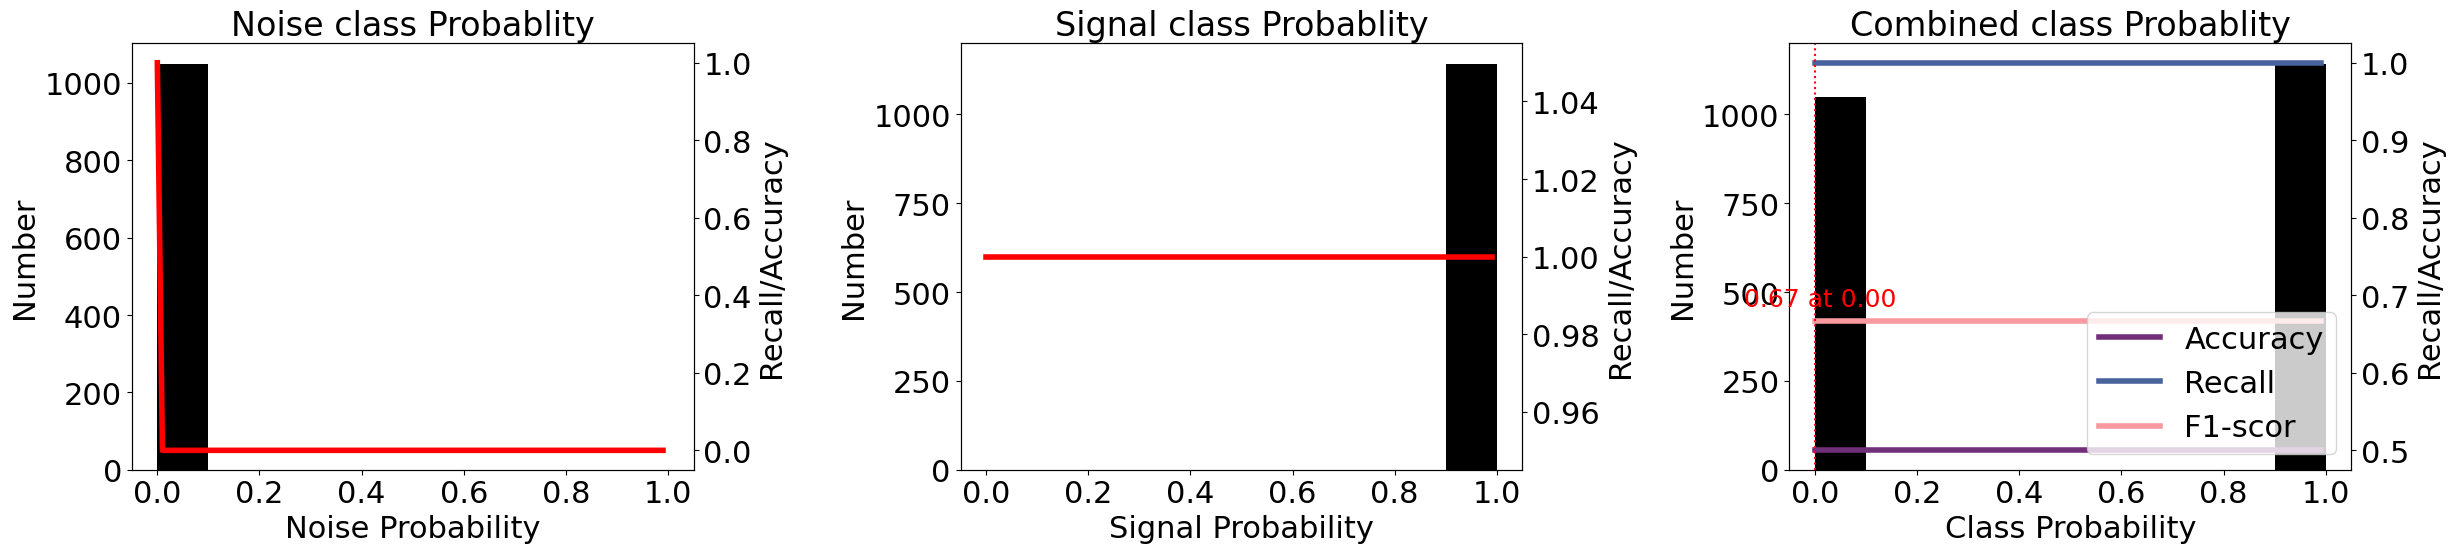

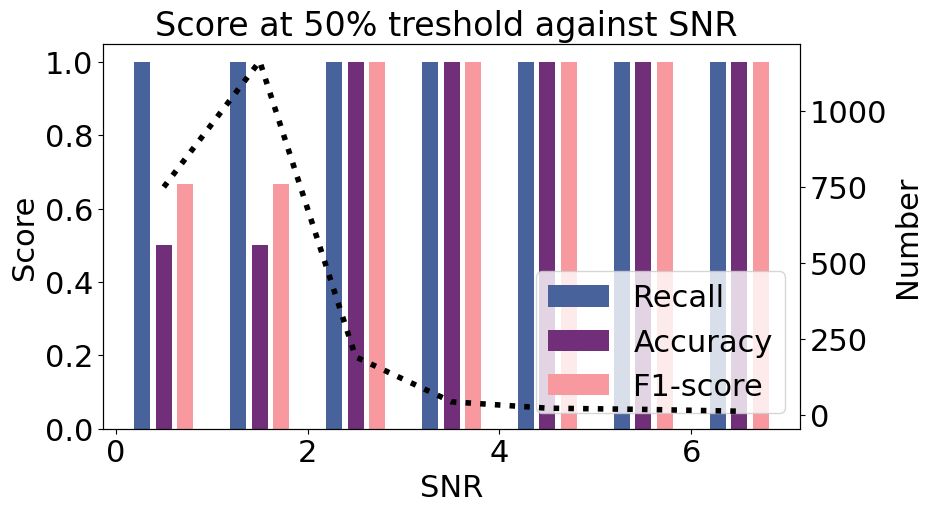

In [175]:
f1,f2, L = plotprobs(pred_listPhase1,labels)
BestP1['PhaseNet'] = L[0]
BestT1['PhaseNet'] = L[1]
f1.savefig("Figure/PhaseNet_Prob_OD.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/PhaseNet_Snr_OD.png", dpi=100, bbox_inches='tight')

## OBSTransformer

In [177]:
# Load the pre-trained model
print(OBSTransformer.list_pretrained())
model = OBSTransformer.from_pretrained("obst2024")
model.to('cpu:0')

['obst2024']


OBSTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.2, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d

In [178]:
%autoawait on
pred_list = []
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )

pred_list_OBS1 = np.array(pred_list)

100%|██████████| 2193/2193 [02:47<00:00, 13.06it/s]


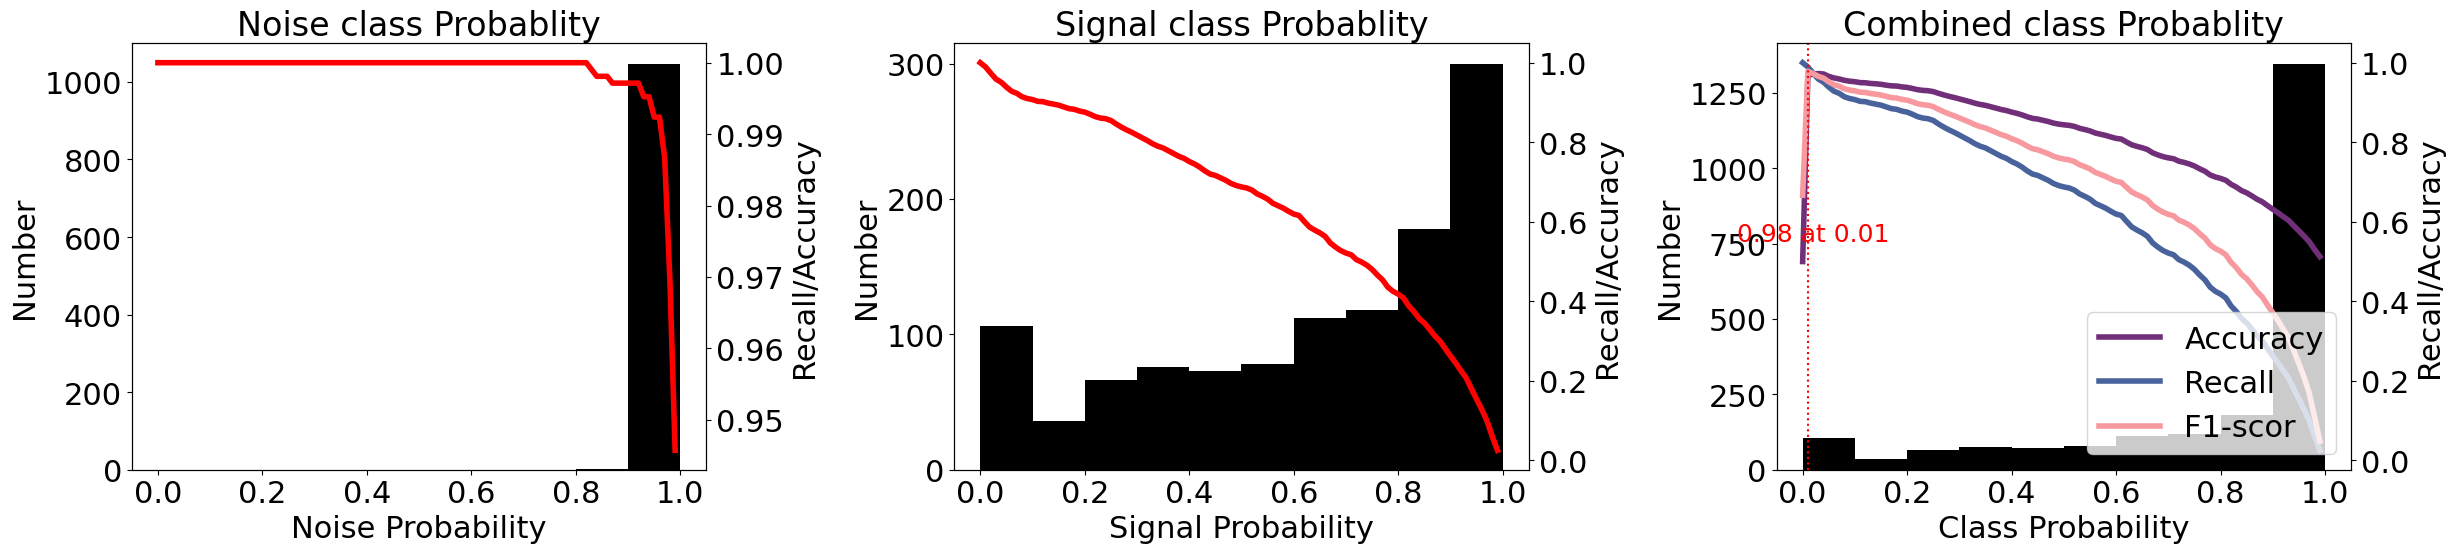

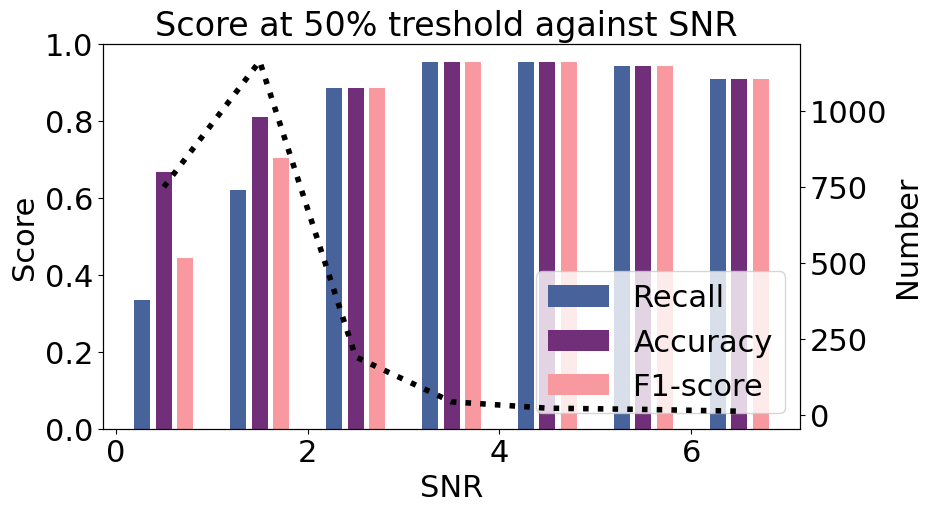

In [179]:
f2,f2, L = plotprobs(pred_list_OBS1,labels)
BestP1['OBS'] = L[0]
BestT1['OBS'] = L[1]
f1.savefig("Figure/OBST_Prob_OD.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/OBST_Snr_OD.png", dpi=100, bbox_inches='tight')

## TESTING IsAE

In [180]:
# Initialize the dataset For Natural Trained Earthquakes
dataset_IsAE = CustomWaveformDataset_IsAE(paths, labels, times, waveforms,Spectrogram)

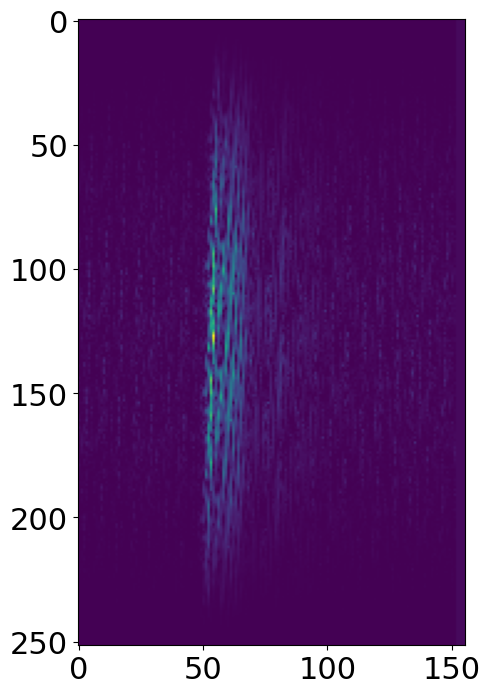

In [187]:
plt.figure(figsize=(5,10))
plt.imshow(Spectrogram[0][0])
plt.show()

In [188]:
device = 'cpu:0'
model = torch.jit.load(f'Classifier_vVOS_AVGPOOL_5_40.pt',map_location=device).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

model.eval()

RecursiveScriptModule(
  original_name=Classifier
  (encoder): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Conv2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=Conv2d)
    (9): RecursiveScriptModule(original_name=ReLU)
    (10): RecursiveScriptModule(original_name=Conv2d)
  )
  (classify): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(or

In [189]:
prob = []
for data in tqdm(dataset_IsAE):
    with torch.no_grad(): 
        img, y_true = data
        img = img.unsqueeze(0).to(device).float()
        logits = model(img)
        p = logits.cpu().numpy()
        prob.append(logits[0][0].cpu())
pred_list_IsAE1 = np.array(prob)    

100%|██████████| 2193/2193 [00:04<00:00, 530.39it/s]


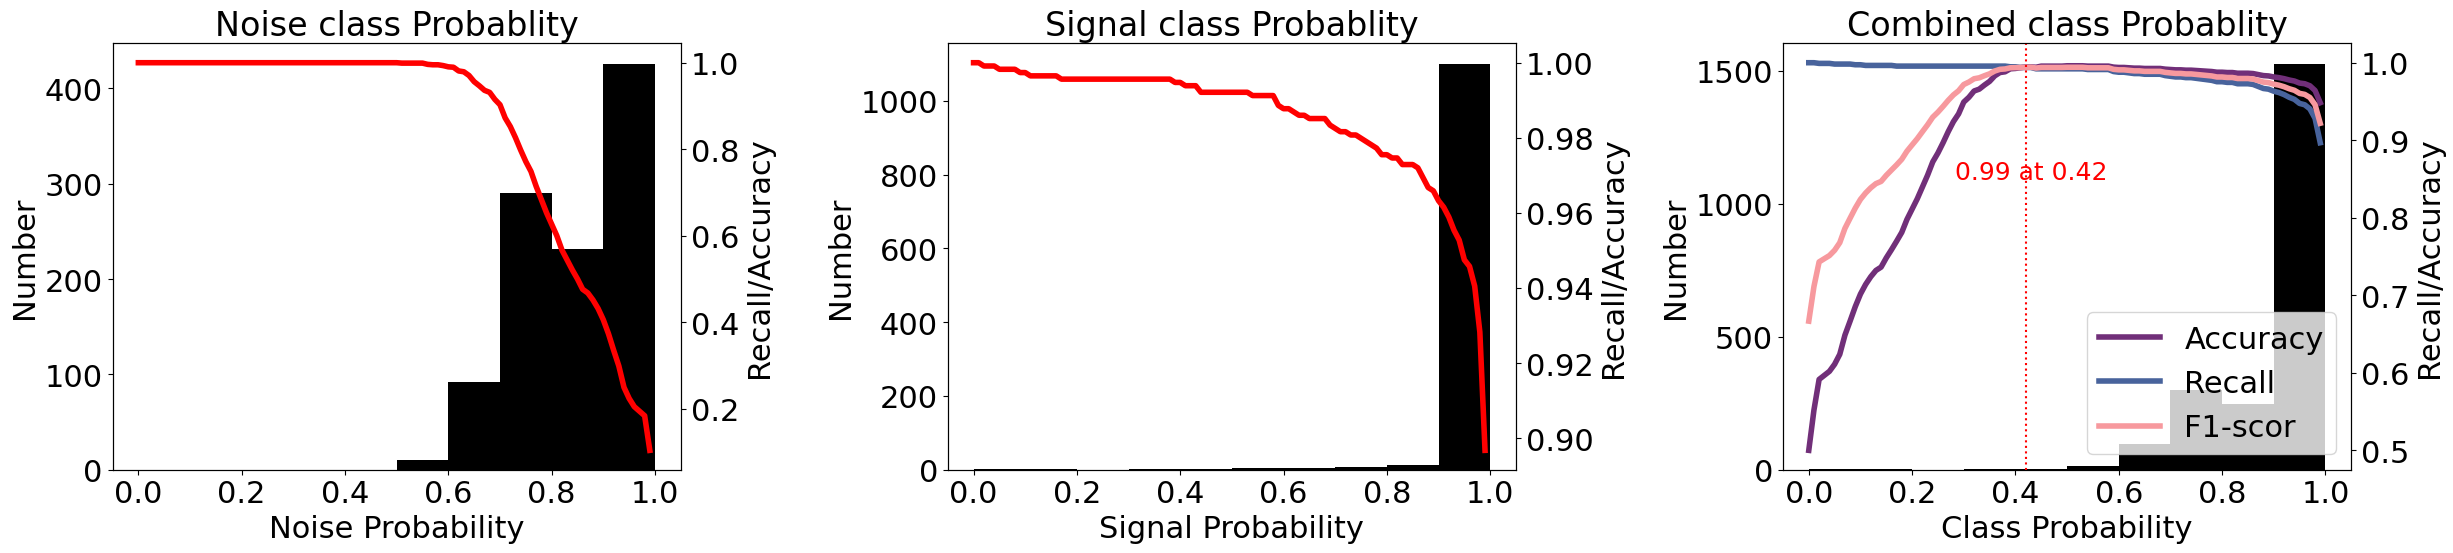

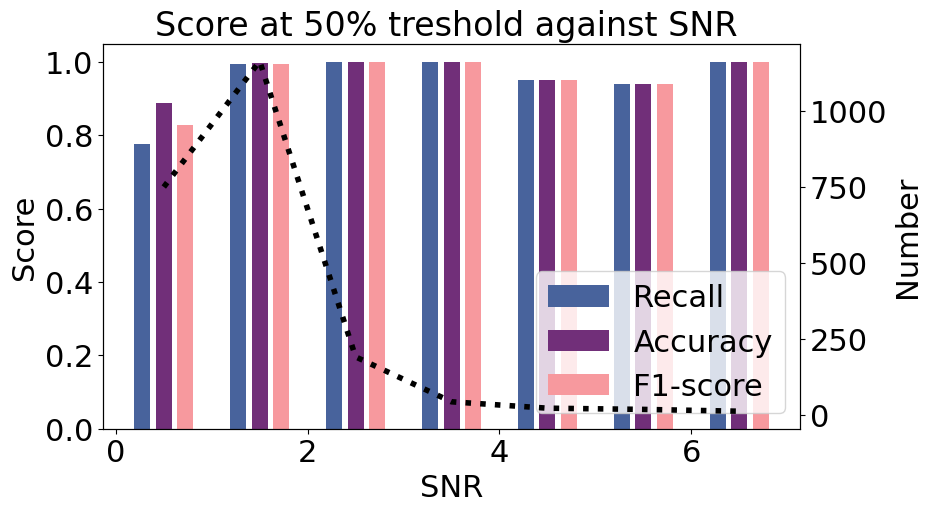

In [190]:
f1,f2, L = plotprobs(pred_list_IsAE1,labels)
BestP1['IsAE'] = L[0]
BestT1['IsAE'] = L[1]
f1.savefig("Figure/IsAE_Prob_OD.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/IsAE_Snr_OD.png", dpi=100, bbox_inches='tight')

# Testing on SeisBench Available Models and IsAE on GlassBead AENet Data

## load data

In [191]:
file = 'dataset_GlassBead_AENet'
with h5py.File(f'{file}.h5', 'r') as f:
    # Load waveforms and labels

    labels = f['labels'][:]
    waveforms = f['waveforms'][:]
    # Load metadata
    paths = f.attrs['paths']
    Spectrogram  = f['spectrograms'][:]
    
    SNR = MakeSNR(waveforms)

print(f"Dataset loaded from '{file}.h5'.")
print('Number of elements : ',len(paths))

# Initialize the dataset For Natural Trained Earthquakes
dataset = CustomWaveformDataset_Seisbench(paths, labels, times, waveforms)

Dataset loaded from 'dataset_GlassBead_AENet.h5'.
Number of elements :  2127


In [204]:
# Initialize dict
chrono = {}
BestP2 ={}
BestT2 = {}

In [193]:
len(waveforms[0][0])

8000

In [194]:
print(dataset[0][0])  # Should be (3, num_samples) for 3-component data
print(dataset[0])

3 Trace(s) in Stream:
...Component_1 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_2 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
...Component_3 | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:21.910000Z | 100.0 Hz, 8192 samples
(<obspy.core.stream.Stream object at 0x7fb8182aa240>, tensor(1))


## Cred

In [205]:
%autoawait on
# Load the pre-trained model
print(CRED.list_pretrained())
model = CRED.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'lendb', 'original', 'scedc', 'stead']


CRED(
  (conv1): Conv2d(3, 8, kernel_size=(9, 9), stride=(2, 2), padding=(4, 4))
  (cnn_block1): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(8, 8, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (cnn_block2): BlockCNN(
    (convs): ModuleList(
      (0-1): 2 x Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (norms): ModuleList(
      (0-1): 2 x BatchNorm2d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (lstm_block): BlockBiLSTM(
    (dropout): Dropout(p=0.3, inplace=False)
    (lstms): ModuleList(
      (0): LSTM(176, 64, batch_first=True, bidirectional=True)
      (1): LSTM(128, 64, batch_first=True, bidirectional=True)
    )
  )
  (lstm): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.

In [206]:
pred_list = []
tic()
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono['Cred']=tac()
pred_list_Cred2 = np.array(pred_list)

100%|██████████| 2127/2127 [01:21<00:00, 26.06it/s]


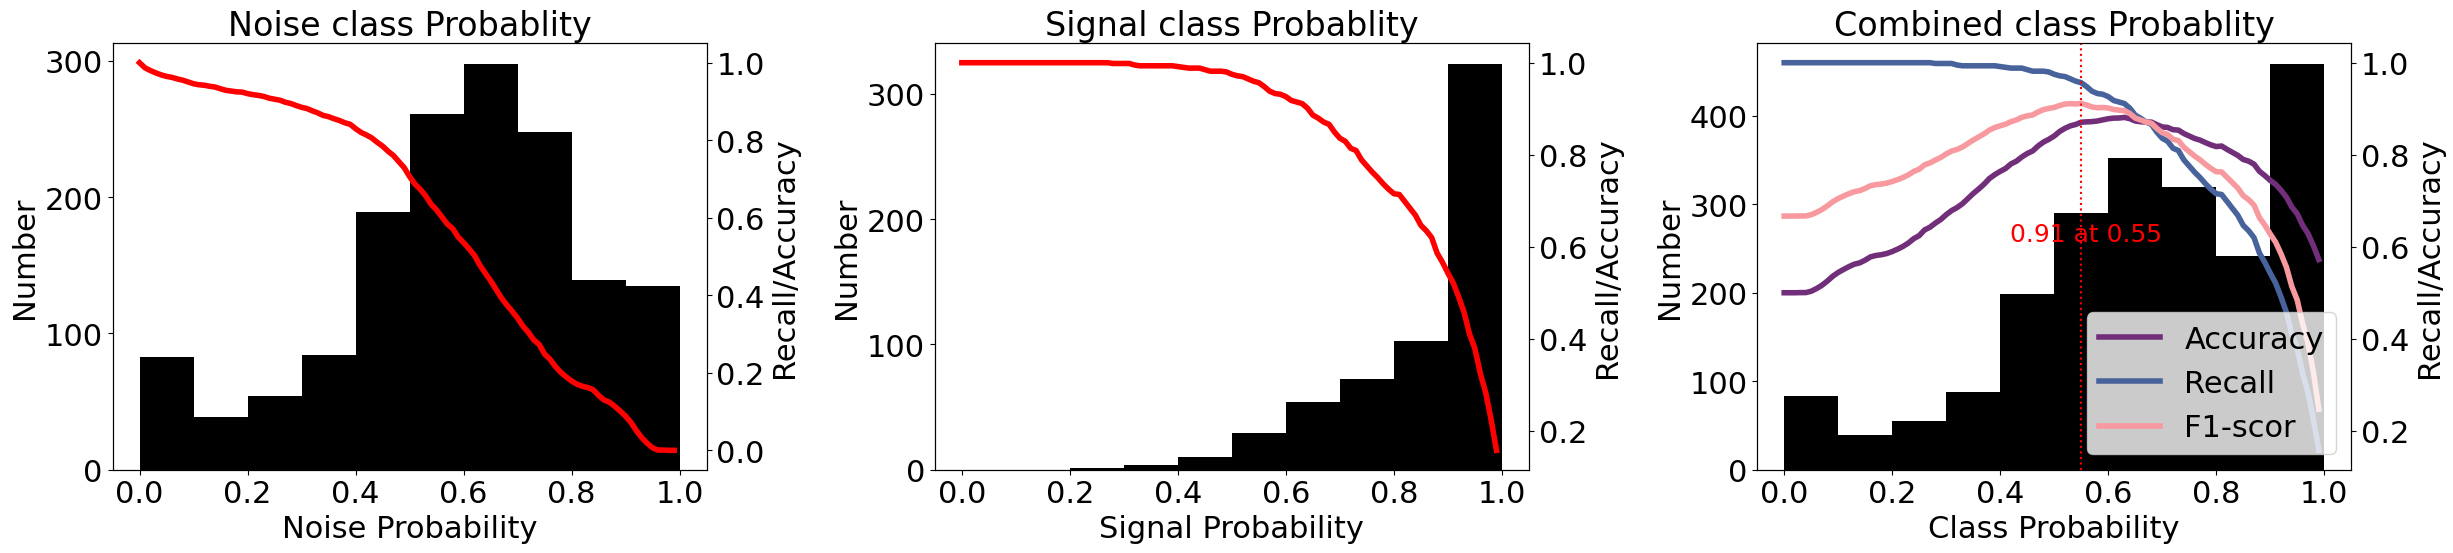

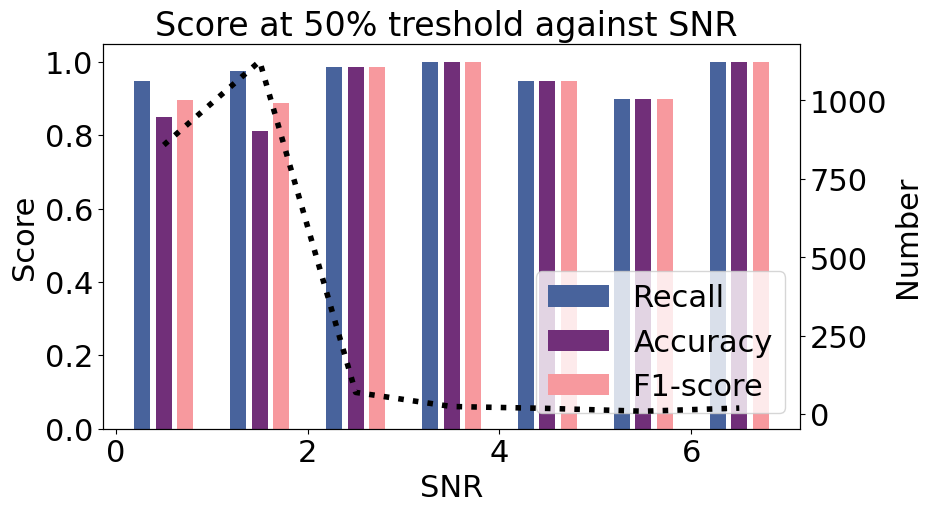

In [207]:
f1,f2, L = plotprobs(pred_list_Cred2,labels)
BestP2['Cred'] = L[0]
BestT2['Cred'] = L[1]
f1.savefig("Figure/CRED_Prob_GB.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/CRED_Snr_GB.png", dpi=100, bbox_inches='tight')

## EQTransformer

In [208]:
# Load the pre-trained model
print(EQTransformer.list_pretrained())
model = EQTransformer.from_pretrained("original")
model.to('cpu:0')


['ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'obs', 'original', 'original_nonconservative', 'scedc', 'stead', 'volpick']


EQTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.1, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(

In [209]:

pred_list = []
tic()
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono['EQT']=tac()
pred_list_EQT2 = np.array(pred_list)

100%|██████████| 2127/2127 [03:39<00:00,  9.71it/s]


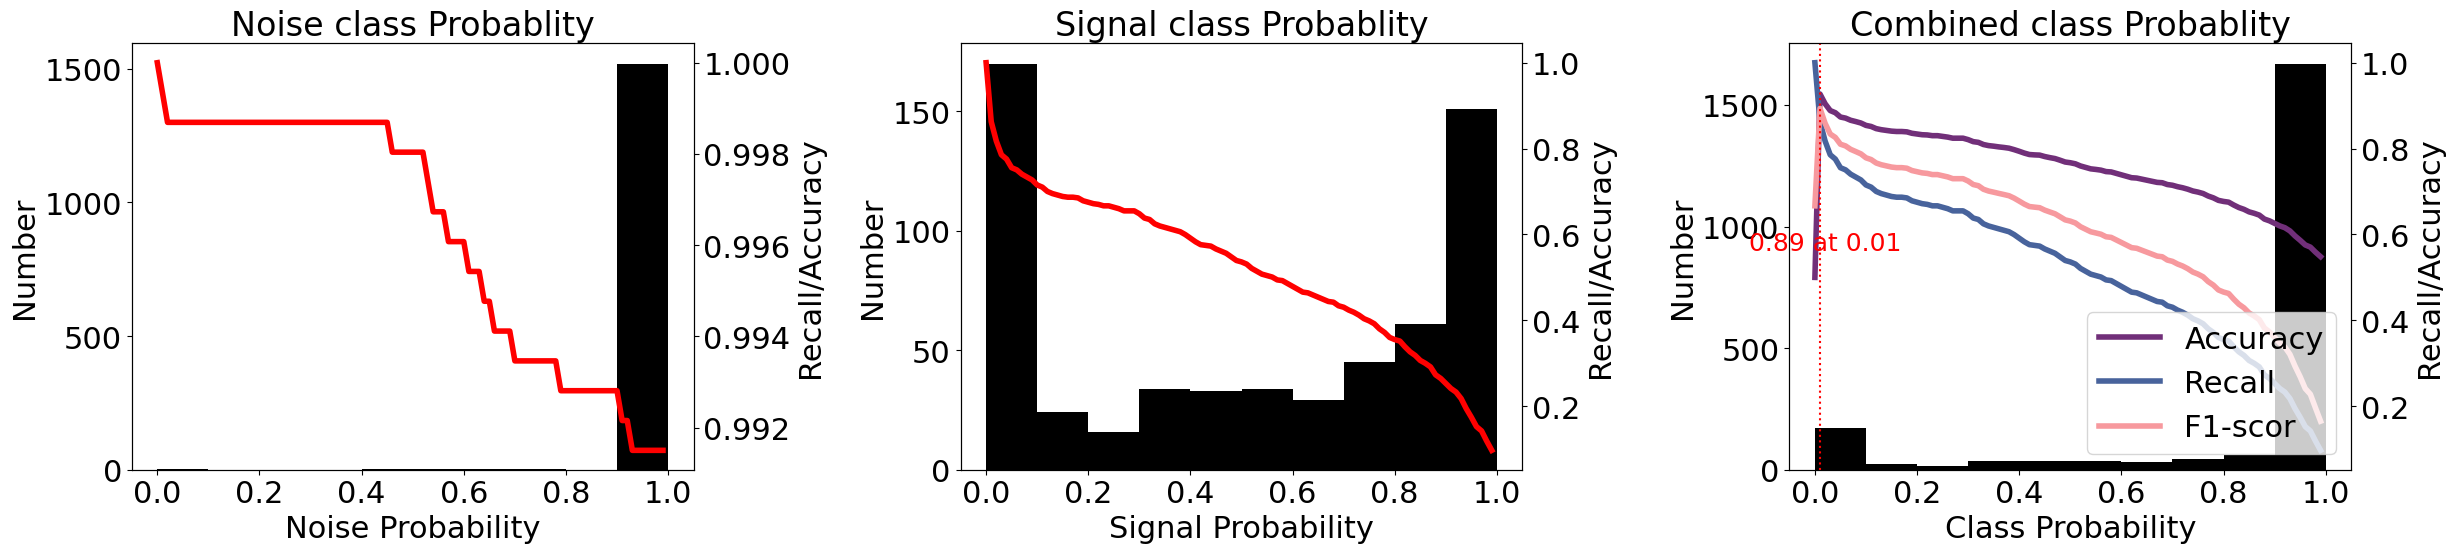

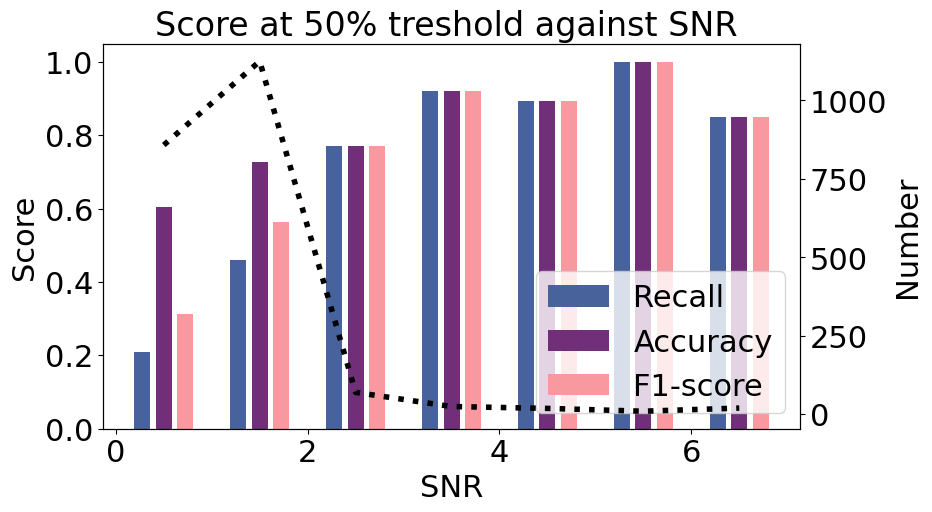

In [210]:
f1,f2, L = plotprobs(pred_list_EQT2,labels)
BestP2['EQT'] = L[0]
BestT2['EQT'] = L[1]
f1.savefig("Figure/EQT_Prob_GB.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/EQT_Snr_GB.png", dpi=100, bbox_inches='tight')

## GPD

In [211]:
## # Load the pre-trained PhaseNet model
print(GPD.list_pretrained())
model = GPD.from_pretrained("original")
model.to('cpu:0')

['dummy', 'ethz', 'geofon', 'instance', 'iquique', 'lendb', 'neic', 'original', 'scedc', 'stead']


GPD(
  (conv1): Conv1d(3, 32, kernel_size=(21,), stride=(1,), padding=(10,))
  (bn1): BatchNorm1d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(15,), stride=(1,), padding=(7,))
  (bn2): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv1d(64, 128, kernel_size=(11,), stride=(1,), padding=(5,))
  (bn3): BatchNorm1d(128, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv1d(128, 256, kernel_size=(9,), stride=(1,), padding=(4,))
  (bn4): BatchNorm1d(256, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=6400, out_features=200, bias=True)
  (bn5): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=200, out_features=200, bias=True)
  (bn6): BatchNorm1d(200, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=200, out_featu

In [212]:
pred_list = []
tic()
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono['GPD']=tac()
pred_list_GPD2 = np.array(pred_list)

100%|██████████| 2127/2127 [11:10<00:00,  3.17it/s]


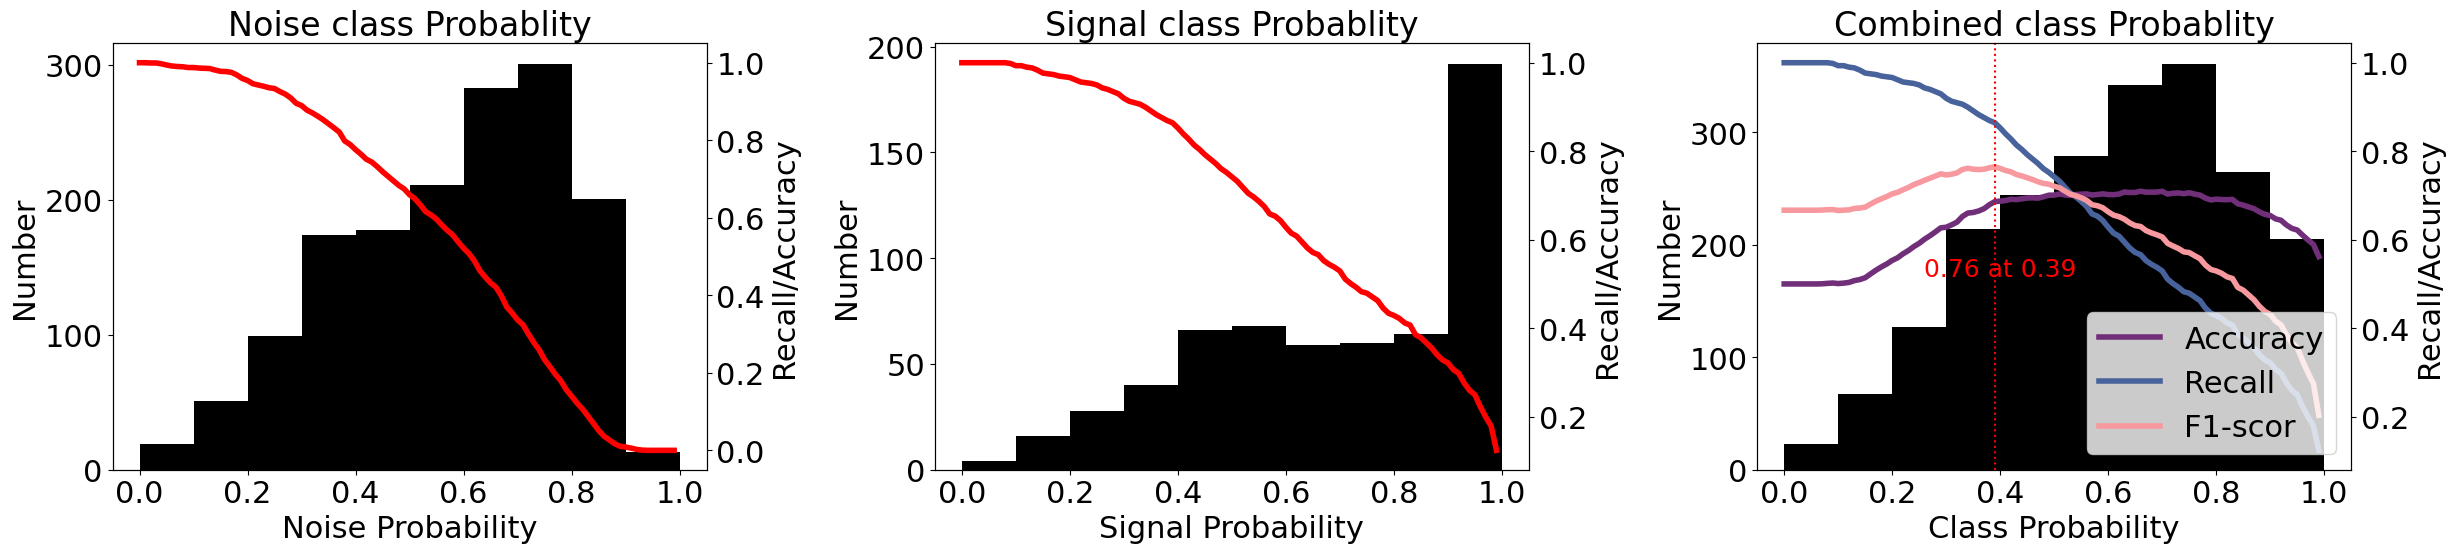

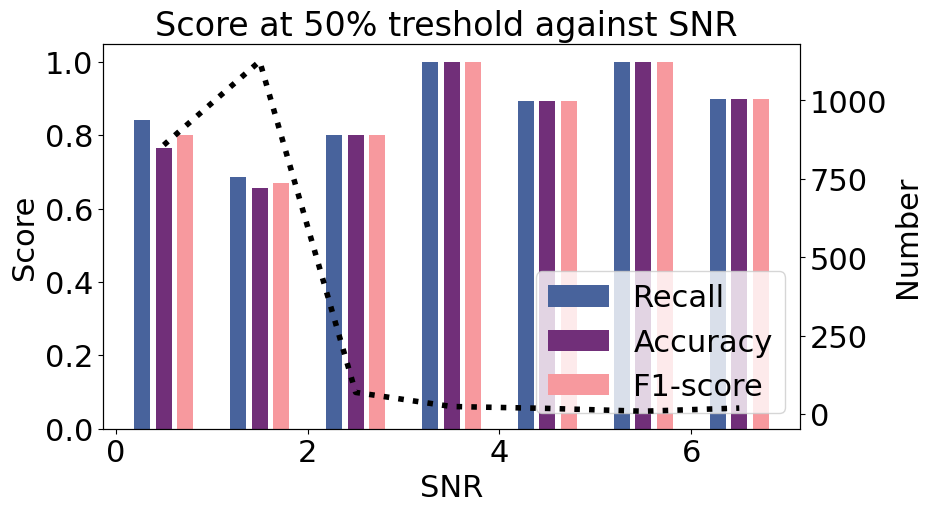

In [218]:
f1,f2, L = plotprobs(pred_list_GPD2,labels)
BestP2['GPD'] = L[0]
BestT2['GPD'] = L[1]
f1.savefig("Figure/GPD_Prob_GB.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/GPD_Snr_GB.png", dpi=100, bbox_inches='tight')

## PhaseNet

In [214]:
# Load the pre-trained PhaseNet model
print(PhaseNet.list_pretrained())
model = PhaseNet.from_pretrained("original")
model.to('cpu:0')


['diting', 'ethz', 'geofon', 'instance', 'iquique', 'jma', 'jma_wc', 'lendb', 'neic', 'obs', 'original', 'phasenet_sn', 'pisdl', 'scedc', 'stead', 'volpick']


PhaseNet(
  (inc): Conv1d(3, 8, kernel_size=(7,), stride=(1,), padding=same)
  (in_bn): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  (down_branch): ModuleList(
    (0): ModuleList(
      (0): Conv1d(8, 8, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(8, 8, kernel_size=(7,), stride=(4,), padding=(3,), bias=False)
      (3): BatchNorm1d(8, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ModuleList(
      (0): Conv1d(8, 16, kernel_size=(7,), stride=(1,), padding=same, bias=False)
      (1): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(4,), bias=False)
      (3): BatchNorm1d(16, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    )
    (2): ModuleList(
      (0): Conv1d(16, 32, kernel_size=(7,), stride=(1,

In [215]:
%autoawait on
pred_list = []
tic()
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono['PhaseNet']=tac()
pred_list_phase2 = np.array(pred_list)

 17%|█▋        | 351/2127 [00:12<00:57, 30.65it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7fbc09494dc0> is already entered
100%|██████████| 2127/2127 [01:17<00:00, 27.45it/s]


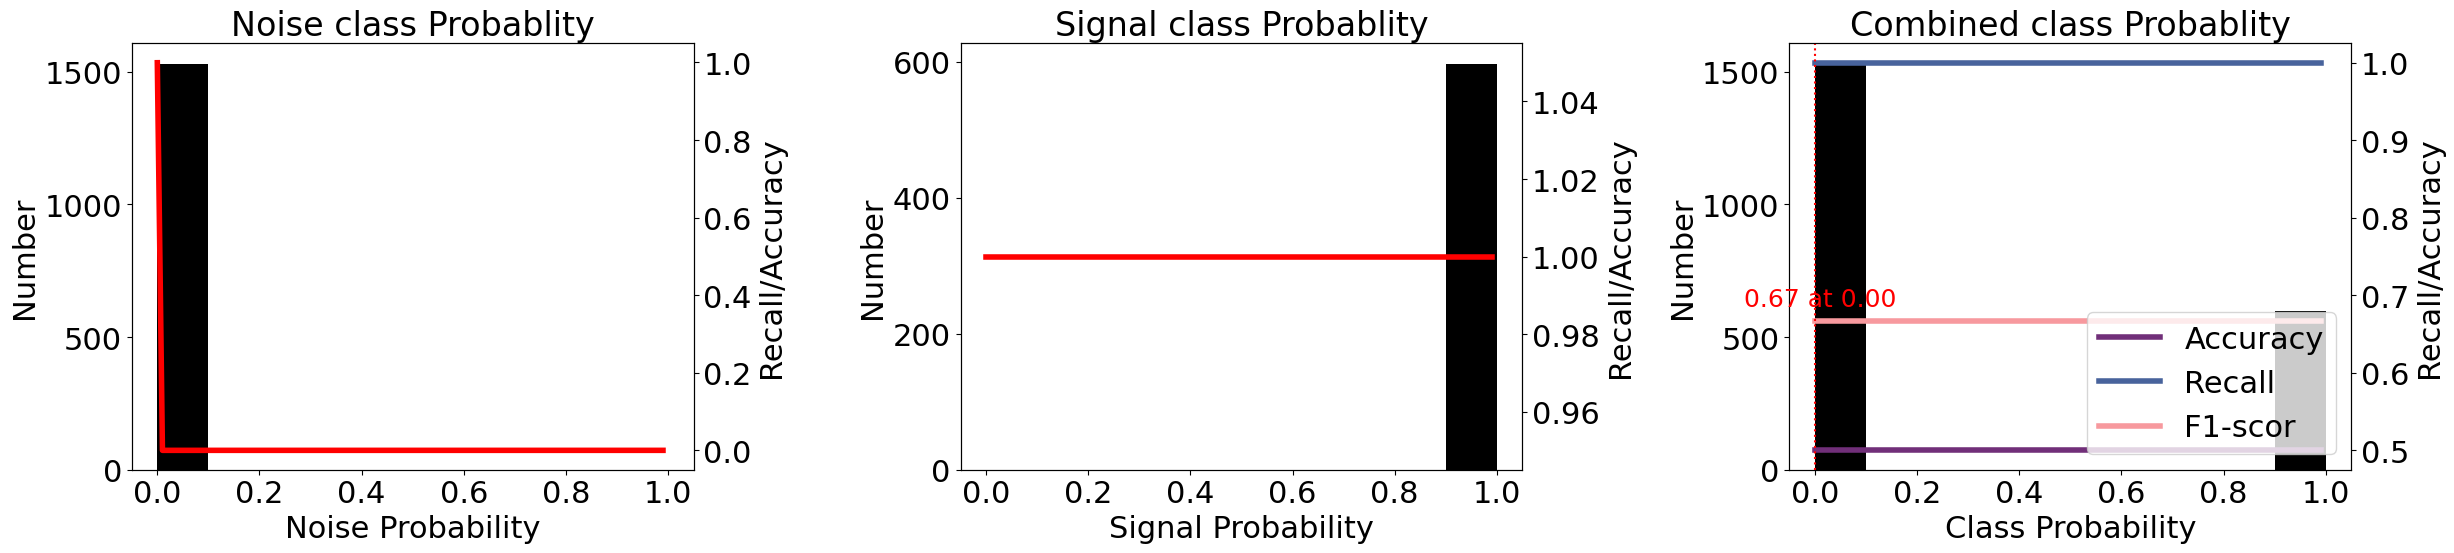

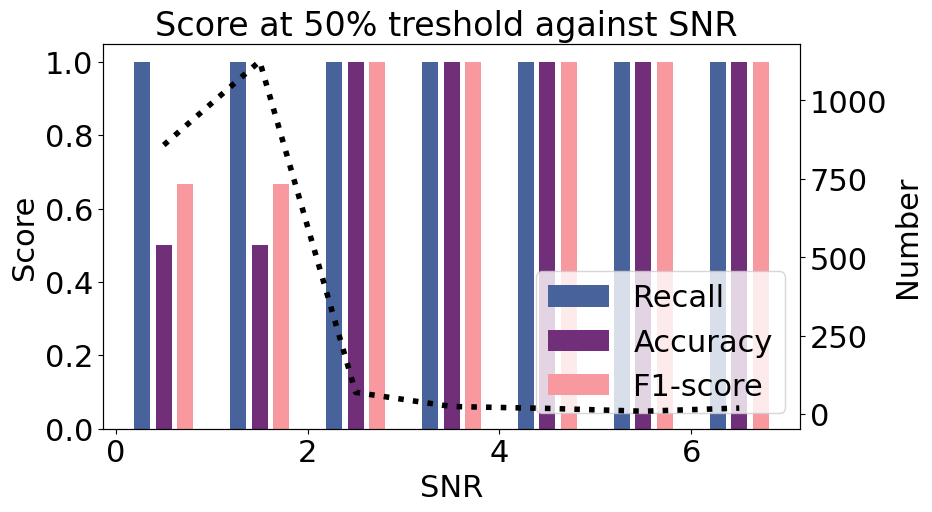

In [219]:
f1,f2, L = plotprobs(pred_list_phase2,labels)
BestP2['PhaseNet'] = L[0]
BestT2['PhaseNet'] = L[1]
f1.savefig("Figure/PhaseNet_Prob_GB.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/PhaseNet_Snr_GB.png", dpi=100, bbox_inches='tight')

## OBSTransformer

In [220]:
# Load the pre-trained model
print(OBSTransformer.list_pretrained())
model = OBSTransformer.from_pretrained("obst2024")
model.to('cpu:0')

['obst2024']


OBSTransformer(
  (encoder): Encoder(
    (convs): ModuleList(
      (0): Conv1d(3, 8, kernel_size=(11,), stride=(1,), padding=(5,))
      (1): Conv1d(8, 16, kernel_size=(9,), stride=(1,), padding=(4,))
      (2): Conv1d(16, 16, kernel_size=(7,), stride=(1,), padding=(3,))
      (3): Conv1d(16, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): Conv1d(32, 32, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    )
    (pools): ModuleList(
      (0-6): 7 x MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (res_cnn_stack): ResCNNStack(
    (members): ModuleList(
      (0-3): 4 x ResCNNBlock(
        (dropout): SpatialDropout1d(
          (dropout): Dropout2d(p=0.2, inplace=False)
        )
        (norm1): BatchNorm1d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d

In [221]:
%autoawait on
pred_list = []
tic()
for i in tqdm(range(len(dataset))):
    preds = model.annotate(dataset[i][0])
    pred_list.append(max(preds[0].data) )
toc()
chrono['OBS'] = tac()
pred_list_OBS2 = np.array(pred_list)

  1%|          | 24/2127 [00:01<02:56, 11.92it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7fbc09494dc0> is already entered
  2%|▏         | 52/2127 [00:04<02:42, 12.74it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x7fbc09494dc0> is already entered
 11%|█         | 224/2127 [00:17<02:17, 13.80it/s]Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/jupyter-septier/

Task was destroyed but it is pending!
task: <Task pending name='Task-263275' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-263276' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-263276' coro=<Kernel.shell_main() running at /home/jupyter-septier/.conda/envs/BenchMark/lib/python3.12/site-packages/ipykernel/kernelbase.py:590> cb=[Task.__wakeup()]>
Task was destroyed but it is pending!
task: <Task pending name='Task-263452' coro=<_async_in_context.<locals>.run_in_context() done, defined at /home/jupyter-se

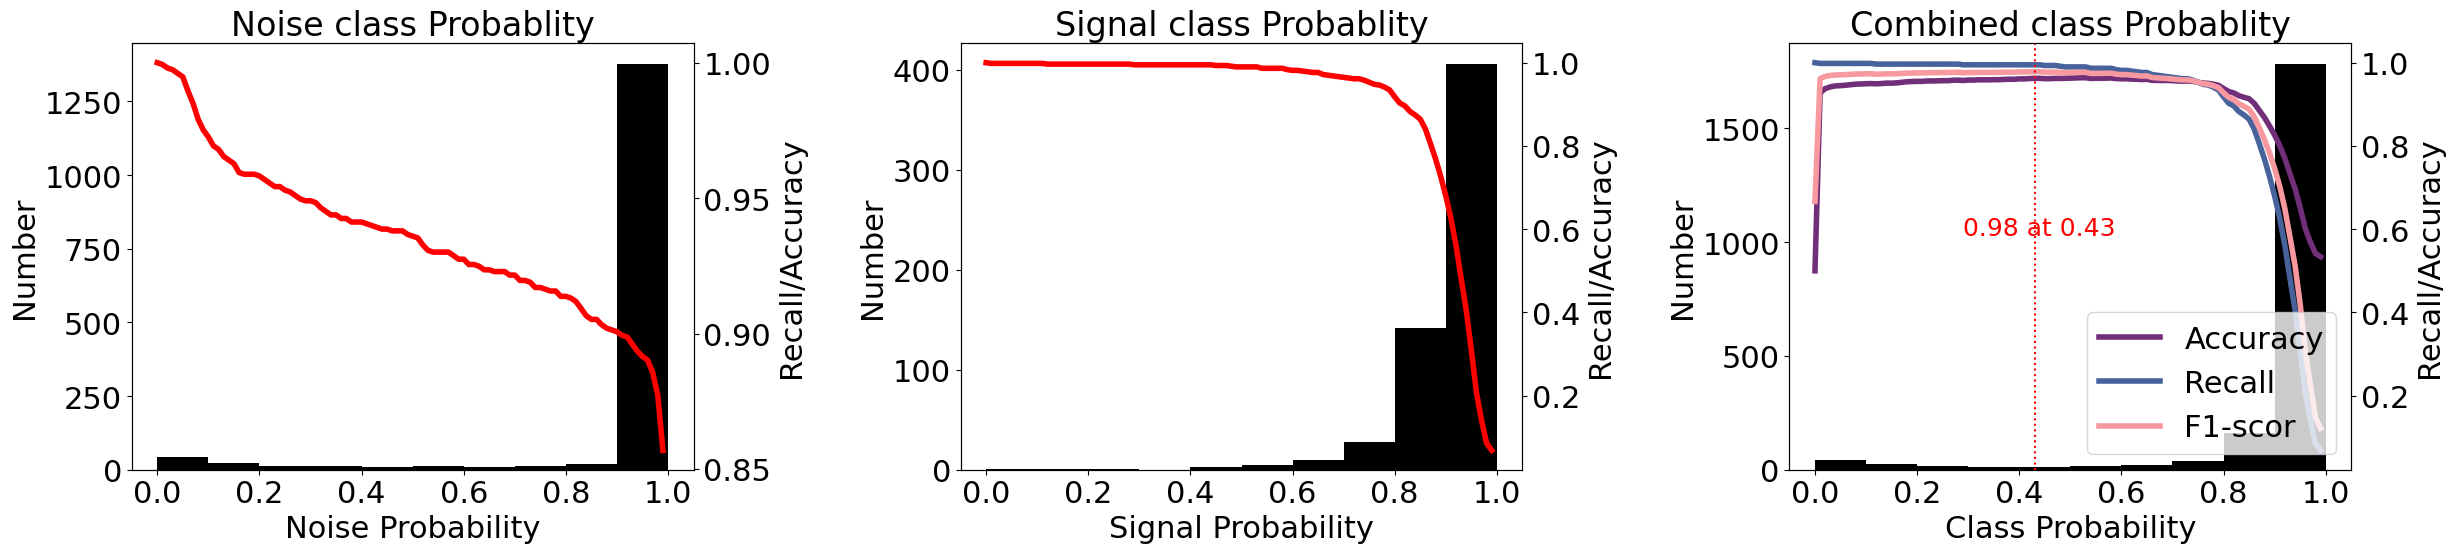

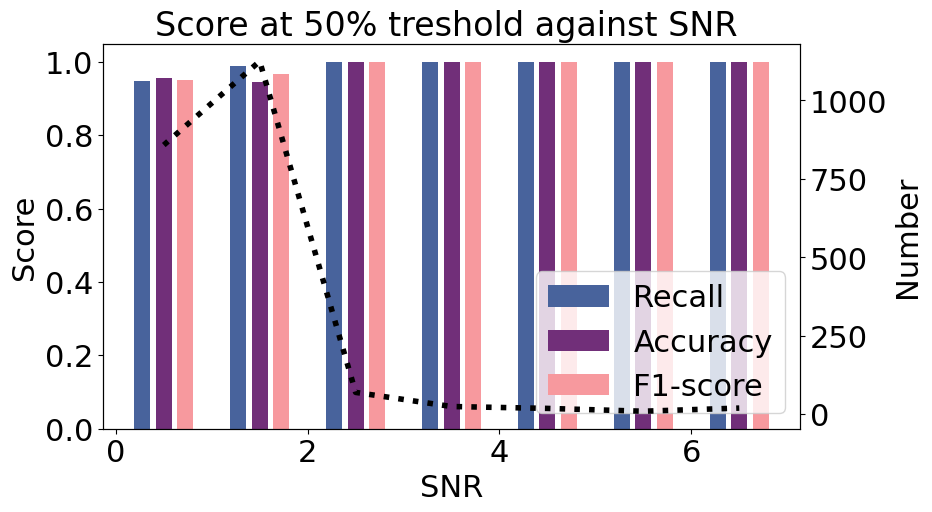

In [222]:
f1,f2, L = plotprobs(pred_list_OBS2,labels)
BestP2['OBS'] = L[0]
BestT2['OBS'] = L[1]
f1.savefig("Figure/OBST_Prob_GB.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/OBST_Snr_GB.png", dpi=100, bbox_inches='tight')

## TESTING IsAE

In [223]:
# Initialize the dataset For Natural Trained Earthquakes
dataset_IsAE = CustomWaveformDataset_IsAE(paths, labels, times, waveforms,Spectrogram)

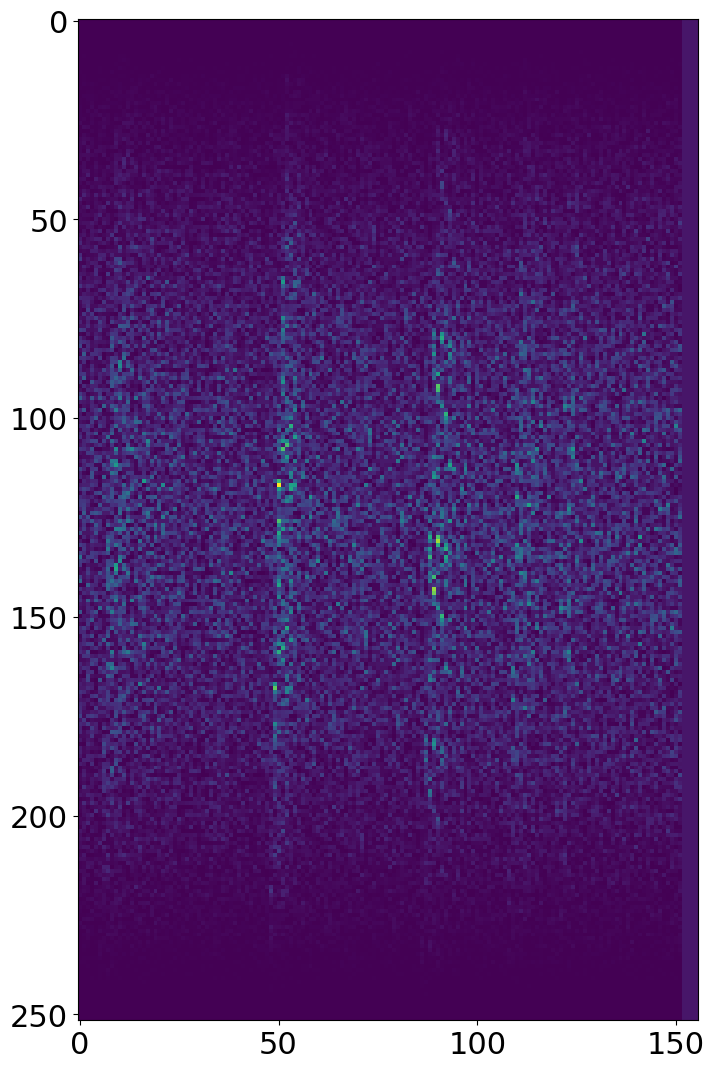

In [224]:
plt.figure(figsize=(8,16))
plt.imshow(Spectrogram[0][0])
plt.show()

In [225]:
device = 'cpu:0'
model = torch.jit.load(f'Classifier_vVOS_AVGPOOL_5_40.pt',map_location=device).to(device)

for param in model.encoder.parameters():
    param.requires_grad = False

model.eval()

RecursiveScriptModule(
  original_name=Classifier
  (encoder): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Conv2d)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Conv2d)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(original_name=Conv2d)
    (5): RecursiveScriptModule(original_name=ReLU)
    (6): RecursiveScriptModule(original_name=Conv2d)
    (7): RecursiveScriptModule(original_name=ReLU)
    (8): RecursiveScriptModule(original_name=Conv2d)
    (9): RecursiveScriptModule(original_name=ReLU)
    (10): RecursiveScriptModule(original_name=Conv2d)
  )
  (classify): RecursiveScriptModule(
    original_name=Sequential
    (0): RecursiveScriptModule(original_name=Linear)
    (1): RecursiveScriptModule(original_name=ReLU)
    (2): RecursiveScriptModule(original_name=Linear)
    (3): RecursiveScriptModule(original_name=ReLU)
    (4): RecursiveScriptModule(or

In [226]:
prob = []
tic()
for data in tqdm(dataset_IsAE):
    with torch.no_grad(): 
        img, y_true = data
        img = img.unsqueeze(0).to(device).float()
        logits = model(img)
        p = logits.cpu().numpy()
        prob.append(logits[0][0].cpu())
toc()
chrono['IsAE']= tac()
pred_lis_IsAE2 = np.array(prob)    

100%|██████████| 2127/2127 [00:03<00:00, 543.98it/s]


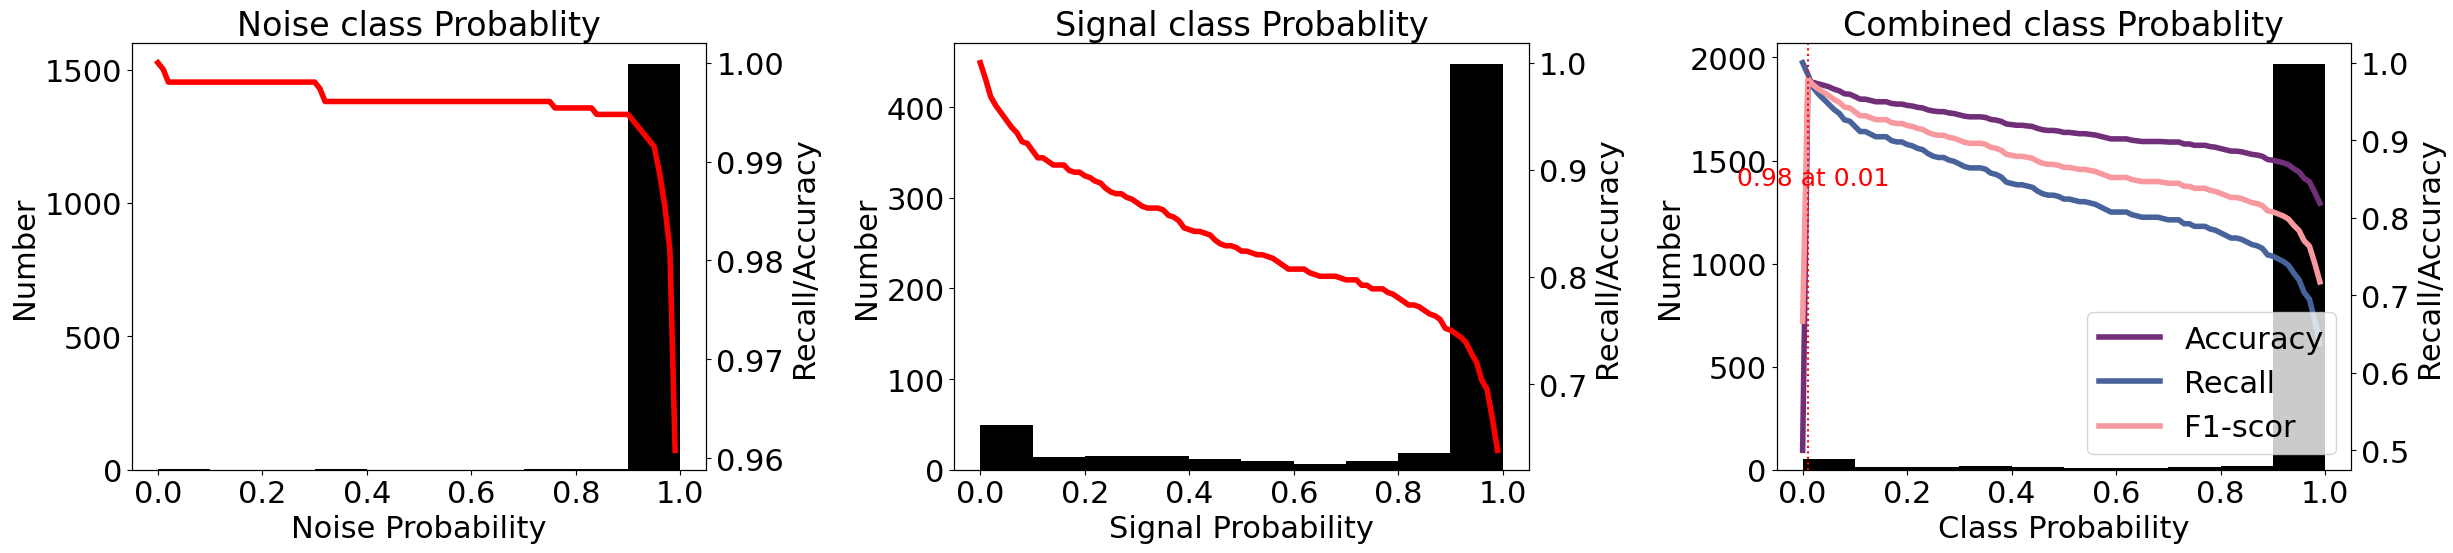

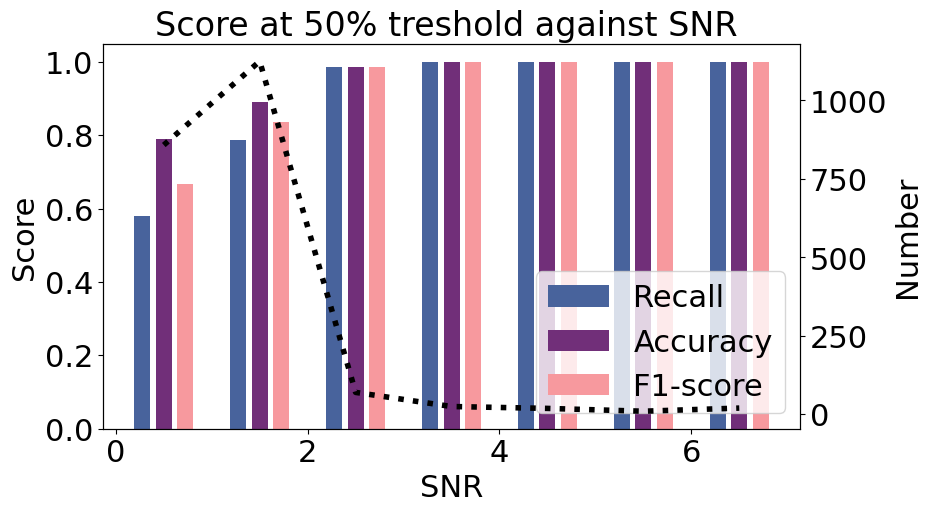

In [233]:
f1,f2, L = plotprobs(pred_lis_IsAE2,labels)
BestP2['IsAE'] = L[0]
BestT2['IsAE'] = L[1]
f1.savefig("Figure/IsAE_Prob_GB.png", dpi=100, bbox_inches='tight')
f2.savefig("Figure/IsAE_Snr_GB.png", dpi=100, bbox_inches='tight')

## Clock Figure

In [228]:
chrono2  = dict(sorted(chrono.items(), key=lambda item: item[1]))

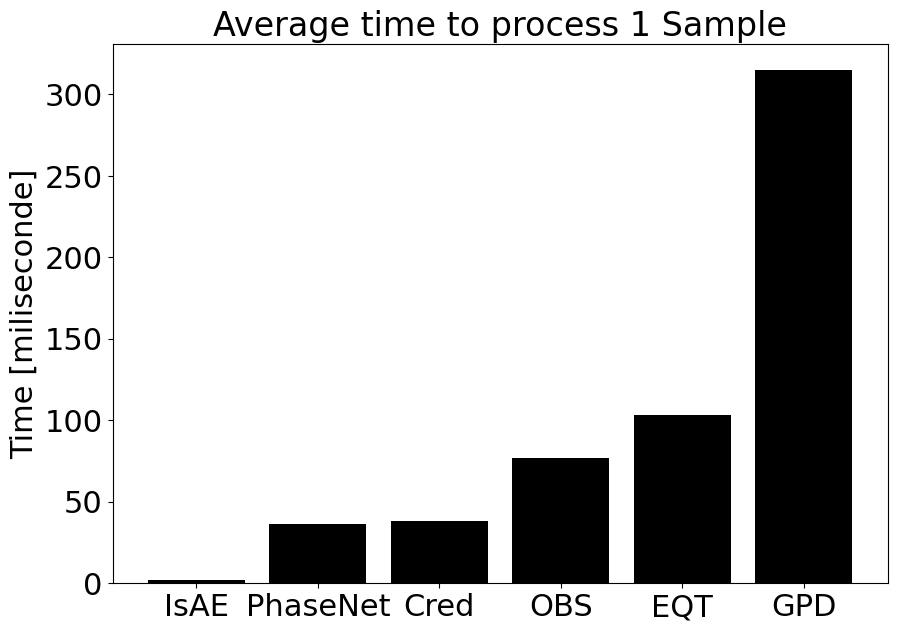

In [230]:
plt.figure(figsize=(10,7))
clocks_k = list(chrono2.keys())
plt.bar(clocks_k, [ chrono2[x]/len(dataset_IsAE)*1000 for x in clocks_k],color='k' )
plt.ylabel('Time [miliseconde]')
plt.title('Average time to process 1 Sample')
plt.show()

# Merge figure

In [231]:
BestP1,BestT1

({'Cred': np.float64(0.8618386077574995),
  'EQT': np.float64(0.7371735240719826),
  'GPD': np.float64(0.9353830383763277),
  'PhaseNet': np.float64(0.6666666666622222),
  'OBS': np.float64(0.9784320980357724),
  'IsAE': np.float64(0.9942162312803303)},
 {'Cred': np.float64(0.6),
  'EQT': np.float64(0.01),
  'GPD': np.float64(0.74),
  'PhaseNet': np.float64(0.0),
  'OBS': np.float64(0.01),
  'IsAE': np.float64(0.42)})

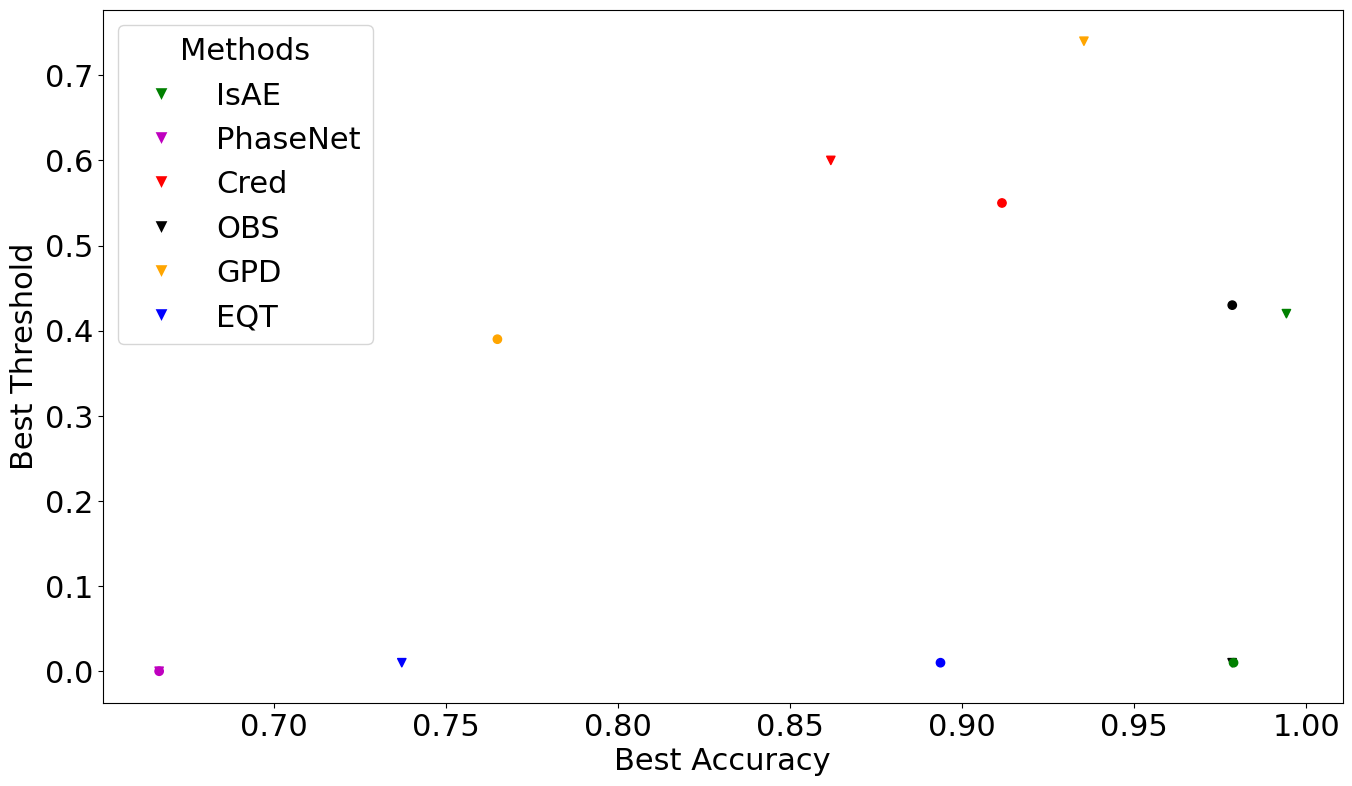

In [234]:
mklist = ['v','o','x','+','8']
colordic = {'IsAE':'g','PhaseNet':'m','Cred':'r','OBS':'k','GPD':'orange','EQT':'b'}
plt.figure(figsize=(16, 9))
dkey = list(BestP1.keys())
bestP_k = [BestP1[x] for x in list(BestP1.keys())]
bestT_k = [BestT1[x] for x in list(BestP1.keys())]
Colortemp = [colordic[x] for x in list(BestP1.keys())]

# Scatter plot
scatter = plt.scatter(bestP_k, bestT_k, color=Colortemp, marker='v')


dkey = list(BestP2.keys())
bestP_k = [BestP2[x] for x in list(BestP2.keys())]
bestT_k = [BestT2[x] for x in list(BestP2.keys())]
Colortemp = [colordic[x] for x in list(BestP2.keys())]

# Scatter plot
scatter = plt.scatter(bestP_k, bestT_k, color=Colortemp, marker='o')


# Create legend handles
legend_labels = list(colordic.keys())
legend_colors = list(colordic.values())
legend_handles = [plt.Line2D([0], [0], marker='v', color='w', markerfacecolor=color, markersize=10, label=label)
                  for label, color in zip(legend_labels, legend_colors)]

# Add legend
plt.legend(handles=legend_handles, title='Methods')

plt.xlabel('Best Accuracy')
plt.ylabel('Best Threshold')
plt.show()

In [162]:
bestP_k,bestT_k,Colortemp

([np.float64(0.8618386077574995),
  np.float64(0.8618386077574995),
  np.float64(0.9353830383763277)],
 [np.float64(0.6), np.float64(0.6), np.float64(0.74)],
 ['r', 'b', 'orange'])

In [235]:
import os
import re
from PIL import Image, ImageDraw, ImageFont

def combine_figures_vertically(folder_path):
    # Get all PNG files in the folder
    files = [f for f in os.listdir(folder_path) if f.endswith('.png')]

    # Group files by datatype and dataset
    groups = {}
    for file in files:
        model_name, datatype, dataset = re.match(r"([^_]+)_([^_]+)_([^_]+)\.png", file).groups()
        key = (datatype, dataset)
        if key not in groups:
            groups[key] = []
        groups[key].append((model_name, file))

    # Combine figures for each group
    for (datatype, dataset), models_files in groups.items():
        # Open all images for the current datatype and dataset
        images = [Image.open(os.path.join(folder_path, f)) for _, f in models_files]

        # Combine images vertically
        widths, heights = zip(*(img.size for img in images))
        total_height = sum(heights)
        max_width = max(widths)

        combined_img = Image.new('RGB', (max_width, total_height))

        y_offset = 0
        for (model_name, _), img in zip(models_files, images):
            # Add model_name text to the top-left corner of each sub-figure
            draw = ImageDraw.Draw(img)

            font = ImageFont.truetype("FreeMono.ttf", 30)

            draw.text((0, 0), model_name, fill="black", font=font)
            # Paste the image into the combined image
            combined_img.paste(img, (0, y_offset))
            y_offset += img.size[1]

        # Save the combined image
        output_filename = f"combined_{datatype}_{dataset}.png"
        combined_img.save(os.path.join(folder_path, output_filename))

# Example usage
folder_path = "Figure"  # Replace with your folder path
combine_figures_vertically(folder_path)


In [116]:
font = ImageFont.load_default()

# Do Save

In [200]:
import pickle

# Get all global variables
global_vars = globals()

# Filter out PyTorch objects
filtered_vars = {}
for key, value in global_vars.items():
    # Skip PyTorch modules, tensors, and models
    if not (isinstance(value, torch.nn.Module) or
            isinstance(value, torch.Tensor) or
            (hasattr(value, '__module__') and value.__module__.startswith('torch'))):
        filtered_vars[key] = value

# Save the filtered variables
with open('filtered_globals.pkl', 'wb') as f:
    pickle.dump(filtered_vars, f)



RuntimeError: Tried to serialize object __torch__.___torch_mangle_15.Classifier which does not have a __getstate__ method defined!

In [ ]:
# Load

In [ ]:

# Load from file
with open('global_vars.pkl', 'rb') as f:
    loaded_vars = pickle.load(f)

# Update the current environment
globals().update(loaded_vars)
